In [318]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
from pytorch_msssim import ms_ssim

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.ndimage import zoom
from sklearn.model_selection import KFold

In [319]:
COL = '/Users/user/data/research/proton-deuteron/col&ind/col.pkl'
IND = '/Users/user/data/research/proton-deuteron/col&ind/ind.pkl'

masses = pd.read_csv('/Users/user/data/research/proton-deuteron/csv/picky+match.csv')           # BEAMLINE INFO. 

col = pd.read_pickle(COL); 
ind = pd.read_pickle(IND)

col = pd.merge(
    col,
    masses[['run', 'subrun', 'event', 'p', 'm', 'beamline_mass']],
    on=['run', 'subrun', 'event'],
    how='left'
)

ind = pd.merge(
    ind,
    masses[['run', 'subrun', 'event', 'p', 'm', 'beamline_mass']],
    on=['run', 'subrun', 'event'],
    how='left'
)

In [446]:
maxes = col['column_maxes'].values

normalised = []

for i, signal in enumerate(maxes):
    
    minimum = 0
    maximum = np.max(signal)

    if maximum > minimum:
        normalised_signal = (signal - minimum) / (maximum - minimum)
    else:
        normalised_signal = np.zeros_like(signal, dtype=float)
        print(f'Error: Max not greater than min in signal {i}.')

    normalised.append(normalised_signal)

adcdiff = [np.diff(signal) for signal in normalised]
maxdiff = [np.max(diff) for diff in adcdiff]; col['maxdiff'] = maxdiff

/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [ ]:
maxes = ind['column_maxes'].values

normalised = []

for i, signal in enumerate(maxes):
    
    minimum = 0
    maximum = np.max(signal)

    if maximum > minimum:
        normalised_signal = (signal - minimum) / (maximum - minimum)
    else:
        normalised_signal = np.zeros_like(signal, dtype=float)
        print(f'Error: Max not greater than min in signal {i}.')

    normalised.append(normalised_signal)

adcdiff = [np.diff(signal) for signal in normalised]
maxdiff = [np.max(diff) for diff in adcdiff]; ind['maxdiff'] = maxdiff

In [322]:
removed_indices_col = col[~((col['height'] < 100) & (col['width'] < 400))].index
removed_indices_ind = ind[~((ind['height'] < 100) & (ind['width'] < 400))].index


removed_indices = removed_indices_col.union(removed_indices_ind)

col = col[~col.index.isin(removed_indices)]
ind = ind[~ind.index.isin(removed_indices)]

In [323]:
def pad_image(image, target_wh=(1024, 99)):
    """
    Place a 2D image block in the centre of a zero canvas.

    image: 2D np.ndarray, shape (h, w)
    target_wh: (target_width, target_height)
    """
    target_w, target_h = target_wh
    canvas = np.zeros((target_h, target_w), dtype=image.dtype)

    h, w = image.shape
    
    v = int(np.argmax(image[0]))

    a = 512 - v
    
    # Compute top-left corner so image is centred
    y0 = 0
    x0 = a
    y1 = y0 + h
    x1 = x0 + w

    # Place the image block
    canvas[y0:y1, x0:x1] = image

    return canvas

In [324]:
def downsample_image(image, target_shape=(512, 40)):
    scale_y = target_shape[1] / image.shape[0]
    scale_x = target_shape[0] / image.shape[1]
    return zoom(image, (scale_y, scale_x), order=1)  # order=1 for bilinear interpolation

In [325]:
p_c = []
p_i = []

d_c = []
d_i = []

for idx, row in col[col['particle_type'] == 'proton'].iterrows():
    padded = pad_image(
        row['image_intensity'])
    p_c.append(padded)

for idx, row in ind[ind['particle_type'] == 'proton'].iterrows():
    padded = pad_image(
        row['image_intensity'])
    p_i.append(padded)

for idx, row in col[col['particle_type'] == 'deuteron'].iterrows():
    padded = pad_image(
        row['image_intensity'])
    d_c.append(padded)

for idx, row in ind[ind['particle_type'] == 'deuteron'].iterrows():
    padded = pad_image(
        row['image_intensity'])
    d_i.append(padded)

p_c = np.array(p_c)
p_i = np.array(p_i)

d_c = np.array(d_c)
d_i = np.array(d_i)

p_c_d = np.array([downsample_image(img, target_shape=(64, 64)) for img in p_c])
p_i_d = np.array([downsample_image(img, target_shape=(64, 64)) for img in p_i])

d_c_d = np.array([downsample_image(img, target_shape=(64, 64)) for img in d_c])
d_i_d = np.array([downsample_image(img, target_shape=(64, 64)) for img in d_i])

In [326]:
p_i_d.shape, p_c_d.shape, d_i_d.shape, d_c_d.shape

((4867, 64, 64), (4867, 64, 64), (2553, 64, 64), (2553, 64, 64))

In [561]:
deutimages = np.stack([d_c, d_i], axis=1)

In [327]:
p = np.stack([p_c_d, p_i_d], axis=1)            # shape: (N, 2, H, W)
d = np.stack([d_c_d, d_i_d], axis=1)            # shape: (N, 2, H, W)

p = torch.from_numpy(p).float()
d = torch.from_numpy(d).float()

In [328]:
class CAE(nn.Module):
    def __init__(self, input_hw=(240, 240), latent=8):
        super(CAE, self).__init__()
        in_h, in_w = input_hw
        assert in_h % 16 == 0 and in_w % 16 == 0, "input spatial dims must be divisible by 16"

        self.encoder = nn.Sequential(
            nn.Conv2d(2, 32, 5, stride=2, padding=2), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, 5, stride=2, padding=2), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 128, 5, stride=2, padding=2), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 256, 5, stride=2, padding=2), nn.BatchNorm2d(256), nn.ReLU()
        )

        self.h_enc = in_h // 16
        self.w_enc = in_w // 16
        flat_size = 256 * self.h_enc * self.w_enc

        self.fc_enc = nn.Linear(flat_size, latent)
        self.fc_dec = nn.Linear(latent, flat_size)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 5, stride=2, padding=2, output_padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 5, stride=2, padding=2, output_padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 5, stride=2, padding=2, output_padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.ConvTranspose2d(32, 2, 5, stride=2, padding=2, output_padding=1),
            nn.ReLU()  
        )

    def forward(self, x):
        enc = self.encoder(x)            # (B,256,H_enc,W_enc)
        z = enc.view(enc.size(0), -1)    # (B, flat_size)
        z = self.fc_enc(z)               # (B, latent)
        z = self.fc_dec(z)               # (B, flat_size)
        y = z.view(x.size(0), 256, self.h_enc, self.w_enc)  # (B,256,H_enc,W_enc)
        y = self.decoder(y)              # (B,H,W)
        return y

In [329]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Training device:", device)

X = torch.tensor(p, dtype=torch.float32)  # shape (N, 2, H, W)
n_splits = 2
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

epochs = 100
batch_size = 32

fold_train_losses, fold_val_losses = [], []
fold_REs = []
fold_REs_d_d = []

Training device: mps


/var/folders/cm/m55y72dj6cd5lkwrfdb2bpnr0000gp/T/ipykernel_43150/496338505.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(p, dtype=torch.float32)  # shape (N, 2, H, W)



===== Fold 1/2 =====
Epoch 1/100: Train=266.6723103709, Val=184.2182557242
Epoch 2/100: Train=156.1922277475, Val=131.3301434207
Epoch 3/100: Train=113.1460805125, Val=103.9581046662
Epoch 4/100: Train=91.9091407479, Val=95.9865480398
Epoch 5/100: Train=88.3712191396, Val=79.0351092599
Epoch 6/100: Train=69.8179373803, Val=72.1183379285
Epoch 7/100: Train=65.0649429916, Val=60.9727346990
Epoch 8/100: Train=56.6540048525, Val=55.7643744233
Epoch 9/100: Train=52.9006136114, Val=54.2935649822
Epoch 10/100: Train=49.4749445729, Val=50.8867093867
Epoch 11/100: Train=46.4085900443, Val=48.3361470854
Epoch 12/100: Train=43.6921055534, Val=44.2108434950
Epoch 13/100: Train=42.3027260025, Val=53.3696854827
Epoch 14/100: Train=49.9408226509, Val=44.6124505873
Epoch 15/100: Train=39.4874692644, Val=43.4911473510
Epoch 16/100: Train=37.1529931651, Val=40.2792934442
Epoch 17/100: Train=36.0347472104, Val=44.6081099324
Epoch 18/100: Train=38.9125290660, Val=41.3892759100
Epoch 19/100: Train=35.0681

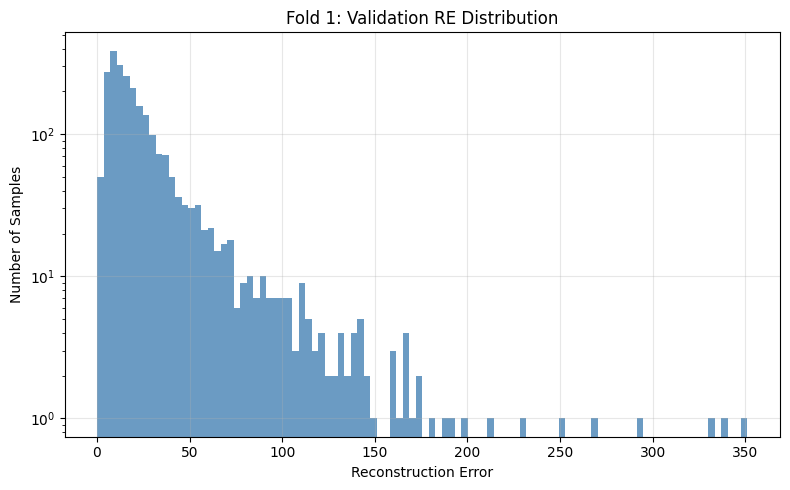

Computing RE on unseen dataset (d)...


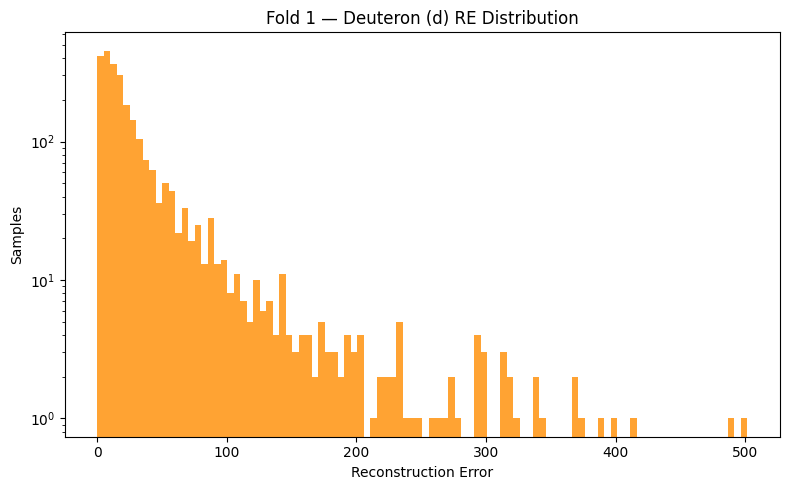


===== Fold 2/2 =====
Epoch 1/100: Train=268.4556335846, Val=183.7571278362
Epoch 2/100: Train=156.5931375677, Val=137.1444327119
Epoch 3/100: Train=114.5236113412, Val=98.8634638848
Epoch 4/100: Train=91.5083025647, Val=86.4084699061
Epoch 5/100: Train=80.8812735421, Val=76.1625707057
Epoch 6/100: Train=71.8146269662, Val=69.1963691464
Epoch 7/100: Train=65.8954088781, Val=67.2794608822
Epoch 8/100: Train=60.6510733567, Val=60.1501711561
Epoch 9/100: Train=53.3496559936, Val=54.9687222196
Epoch 10/100: Train=49.0767846293, Val=52.5307261479
Epoch 11/100: Train=46.8044830917, Val=57.2188791795
Epoch 12/100: Train=45.0871237718, Val=49.9423980713
Epoch 13/100: Train=42.8849790747, Val=43.0428222557
Epoch 14/100: Train=40.6931147637, Val=46.1413227428
Epoch 15/100: Train=39.5486157653, Val=42.0155597538
Epoch 16/100: Train=37.2212708461, Val=39.4153561282
Epoch 17/100: Train=34.9192499186, Val=38.3972223455
Epoch 18/100: Train=32.9076783812, Val=38.6411306332
Epoch 19/100: Train=34.22031

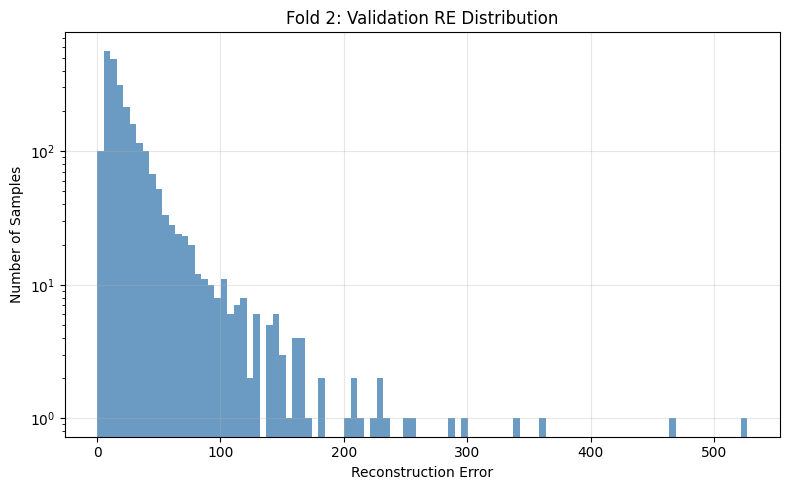

Computing RE on unseen dataset (d)...


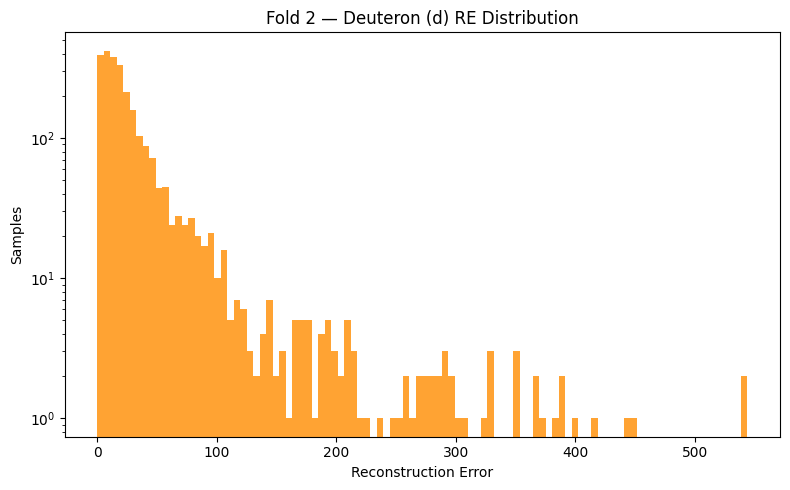

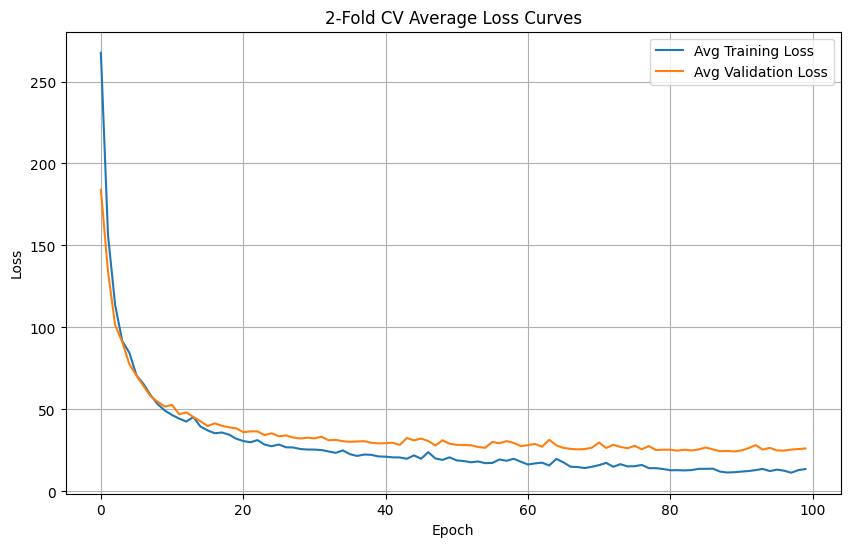

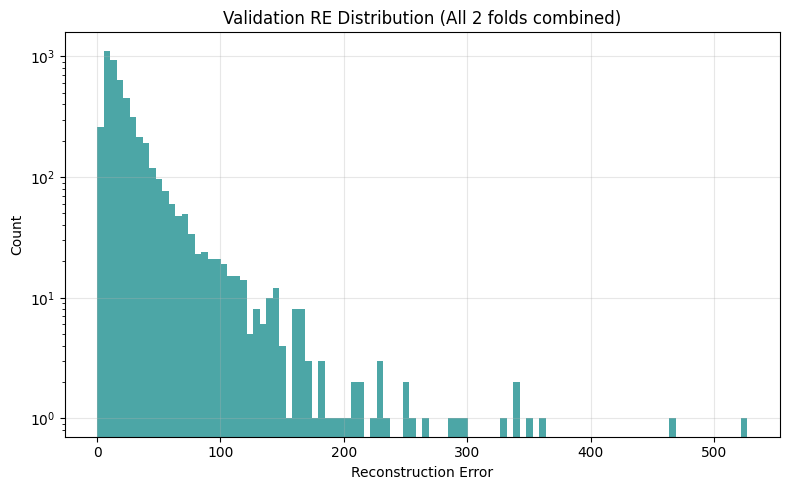

In [330]:
for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    print(f"\n===== Fold {fold+1}/{n_splits} =====")

    train_subset = Subset(X, train_idx)
    val_subset = Subset(X, val_idx)

    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)

    model = CAE(input_hw=(64, 64), latent=16).to(device)
    optim = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    loss_fn = nn.MSELoss()

    train_losses, val_losses = [], []

    # --- Training ---
    for epoch in range(epochs):
        model.train()
        total_train, total_val = 0.0, 0.0

        for xb in train_loader:
            xb = xb.to(device)
            optim.zero_grad()
            preds = model(xb)
            loss = loss_fn(preds, xb)
            loss.backward()
            optim.step()
            total_train += loss.item()

        model.eval()
        with torch.no_grad():
            for xb in val_loader:
                xb = xb.to(device)
                preds = model(xb)
                loss = loss_fn(preds, xb)
                total_val += loss.item()

        train_losses.append(total_train / len(train_loader))
        val_losses.append(total_val / len(val_loader))

        print(f"Epoch {epoch+1}/{epochs}: "
              f"Train={train_losses[-1]:.10f}, Val={val_losses[-1]:.10f}")

    fold_train_losses.append(train_losses)
    fold_val_losses.append(val_losses)

    # -----------------------------
    # 4. Reconstruction error (RE) on this fold's validation set
    # -----------------------------
    print("Computing validation REs...")

    model.eval()
    device_inf = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
    model.to(device_inf)

    X_val_np = torch.stack([val_subset[i] for i in range(len(val_subset))]).cpu().numpy()
    N, C, H, W = X_val_np.shape
    recon_all = np.empty((N, C, H, W), dtype=np.float32)


    latent_dim = model.fc_enc.out_features
    latent_vectors = np.empty((N, latent_dim), dtype=np.float32)

    with torch.no_grad():
        for i in range(0, N, 8):
            j = min(i + 8, N)
            xb = torch.tensor(X_val_np[i:j], dtype=torch.float32).to(device_inf)
            out = model(xb)
            recon_all[i:j] = out.cpu().numpy()

            enc = model.encoder(xb)
            z_flat = enc.flatten(1)
            z = model.fc_enc(z_flat)
            latent_vectors[i:j] = z.cpu().numpy()

            if device_inf.type == "mps":
                try:
                    torch.mps.empty_cache()
                except Exception:
                    pass

    mse_per_pixel = (recon_all - X_val_np) ** 2
    RE_per_sample = mse_per_pixel.mean(axis=(1, 2, 3))
    fold_REs.append(RE_per_sample)

    plt.figure(figsize=(8, 5))
    plt.hist(RE_per_sample, bins=100, color='steelblue', alpha=0.8)
    plt.xlabel("Reconstruction Error")
    plt.ylabel("Number of Samples")
    plt.title(f"Fold {fold+1}: Validation RE Distribution")
    plt.yscale('log')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # ============================================================
    # === Compute Reconstruction Error on Unseen Data (d_d) ======
    # ============================================================

    print("Computing RE on unseen dataset (d)...")

    Xd_np = d.cpu().numpy() if torch.is_tensor(d) else np.array(d, dtype=np.float32)       # unseen data
    N, C, H, W = Xd_np.shape
    recon_all_d = np.empty((N, C, H, W), dtype=np.float32)

    latent_vectors_d = np.empty((N, latent_dim), dtype=np.float32)

    with torch.no_grad():
        for i in range(0, N, 8):
            j = min(i + 8, N)
            xb = torch.tensor(Xd_np[i:j], dtype=torch.float32).to(device_inf)
            out = model(xb)
            recon_all_d[i:j] = out.cpu().numpy()

            enc = model.encoder(xb)
            z_flat = enc.flatten(1)
            z = model.fc_enc(z_flat)
            latent_vectors_d[i:j] = z.cpu().numpy()

            if device_inf.type == "mps":
                try:
                    torch.mps.empty_cache()
                except Exception:
                    pass

    RE_d_d = ((recon_all_d - Xd_np) ** 2).mean(axis=(1, 2, 3))
    fold_REs_d_d.append(RE_d_d)

    plt.figure(figsize=(8, 5))
    plt.hist(RE_d_d, bins=100, color='darkorange', alpha=0.8)
    plt.yscale('log')
    plt.xlabel("Reconstruction Error")
    plt.ylabel("Samples")
    plt.title(f"Fold {fold+1} — Deuteron (d) RE Distribution")
    plt.tight_layout()
    plt.show()

    # torch.save(model.state_dict(), f"msefolds/CAE_fold{fold+1}.pt")
    # np.save(f"msefolds/RE_val_fold{fold+1}.npy", RE_per_sample)
    # np.save(f"msefolds/RE_d_d_fold{fold+1}.npy", RE_d_d)
    # np.save(f"msefolds/latent_val_fold{fold+1}.npy", latent_vectors)
    # np.save(f"msefolds/latent_d_d_fold{fold+1}.npy", latent_vectors_d)

    # print(f"Saved model and RE arrays for fold {fold+1}.")


plt.figure(figsize=(10, 6))
plt.plot(torch.tensor(fold_train_losses).mean(dim=0), label='Avg Training Loss')
plt.plot(torch.tensor(fold_val_losses).mean(dim=0), label='Avg Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title(f'{n_splits}-Fold CV Average Loss Curves')
plt.legend()
plt.grid(True)
plt.show()

all_REs = np.concatenate(fold_REs)
plt.figure(figsize=(8, 5))
plt.hist(all_REs, bins=100, color='teal', alpha=0.7)
plt.yscale('log')
plt.xlabel("Reconstruction Error")
plt.ylabel("Count")
plt.title(f"Validation RE Distribution (All {n_splits} folds combined)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

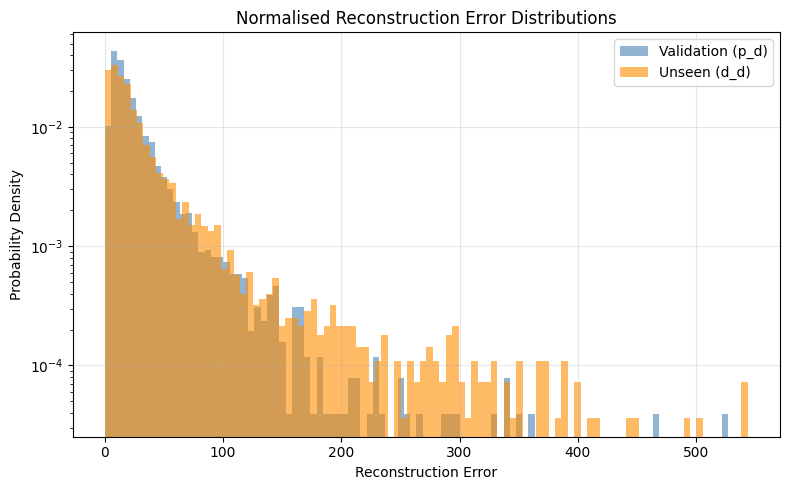

Validation mean RE: 26.4247856140 ± 31.8247947693
Unseen (d_d) mean RE: 31.7720336914 ± 49.7937774658


In [337]:
all_RE_val = np.concatenate(fold_REs)
all_RE_d_d  = np.concatenate(fold_REs_d_d)

plt.figure(figsize=(8, 5))
plt.hist(all_RE_val, bins=100, density=True, alpha=0.6, color='steelblue', label='Validation (p_d)')
plt.hist(all_RE_d_d, bins=100, density=True, alpha=0.6, color='darkorange', label='Unseen (d_d)')
plt.xlabel("Reconstruction Error")
plt.ylabel("Probability Density")
plt.title("Normalised Reconstruction Error Distributions")
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Validation mean RE: {all_RE_val.mean():.10f} ± {all_RE_val.std():.10f}")
print(f"Unseen (d_d) mean RE: {all_RE_d_d.mean():.10f} ± {all_RE_d_d.std():.10f}")

Inference device: mps
recon_all.shape: (2434, 2, 64, 64)
latent_vectors.shape: (2434, 16)
RE_per_sample.shape: (2434,)


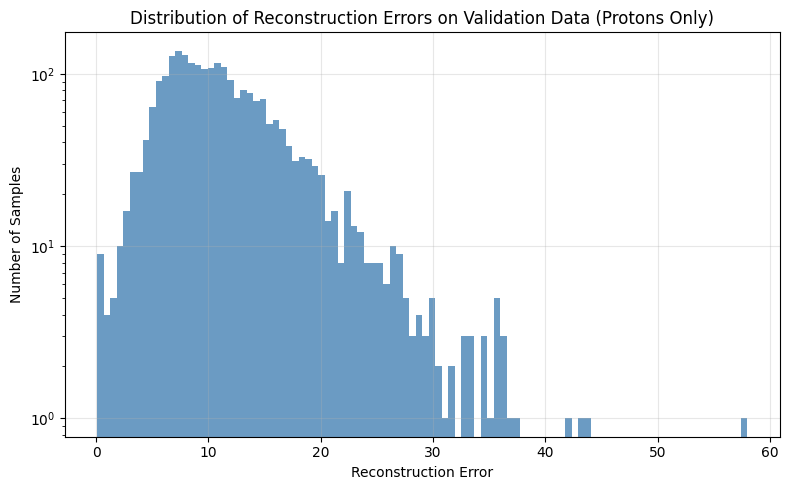

In [338]:
model.eval()

device_inf = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Inference device:", device_inf)

model.to(device_inf)

X_np = torch.stack([train_subset[i] for i in range(len(train_subset))]).cpu().numpy()        # (N, 2, H, W)
N, C, H, W = X_np.shape

batch_size = 8   
recon_all = np.empty((N, C, H, W), dtype=np.float32)

latent_dim = model.fc_enc.out_features
latent_vectors = np.empty((N, latent_dim), dtype=np.float32)

with torch.no_grad():
    for i in range(0, N, batch_size):
        j = min(i + batch_size, N)
        xb_np = X_np[i:j]                                 # (b, 2, H, W)
        xb = torch.tensor(xb_np, dtype=torch.float32).to(device_inf)

        # reconstruction
        out = model(xb)                                   # (b, 2, H, W) on device_inf
        out_cpu = out.cpu().numpy()
        recon_all[i:j] = out_cpu

        # latent
        enc = model.encoder(xb)              # (b, C, h_enc, w_enc)
        z_flat = enc.flatten(1)                           # (b, flat_size)
        z = model.fc_enc(z_flat)                          # (b, latent)
        latent_vectors[i:j] = z.cpu().numpy()

        if device_inf.type == "mps":
            try:
                torch.mps.empty_cache()
            except Exception:
                pass

# per-sample MSE (RE) 
mse_per_pixel = (recon_all - X_np) ** 2
RE_per_sample = mse_per_pixel.mean(axis=(1, 2, 3))        # (N,)

print("recon_all.shape:", recon_all.shape)
print("latent_vectors.shape:", latent_vectors.shape)
print("RE_per_sample.shape:", RE_per_sample.shape)

plt.figure(figsize=(8, 5))
plt.hist(RE_per_sample, bins=100, color='steelblue', alpha=0.8)
plt.xlabel("Reconstruction Error")
plt.ylabel("Number of Samples")
plt.title("Distribution of Reconstruction Errors on Validation Data (Protons Only)")
plt.grid(True, alpha=0.3)
plt.yscale('log')
# plt.xlim(0, 300)
plt.tight_layout()
plt.show()

Inference device: mps
recon_all.shape: (2433, 2, 64, 64)
latent_vectors.shape: (2433, 16)
RE_per_sample.shape: (2433,)


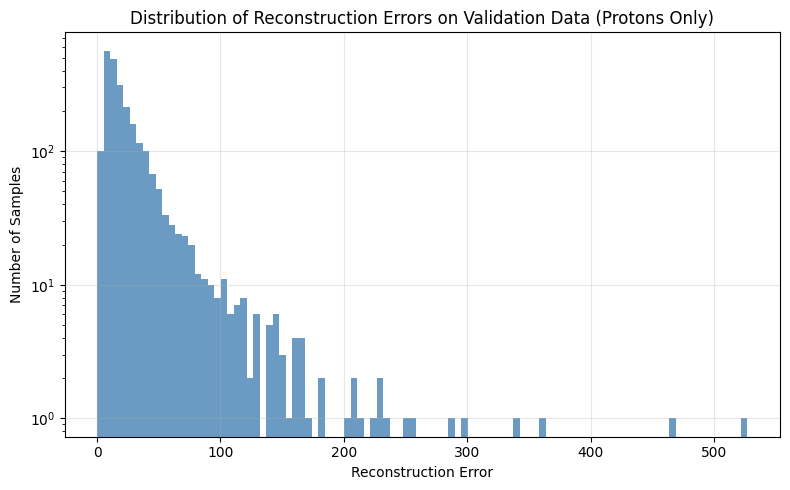

In [339]:
model.eval()

device_inf = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Inference device:", device_inf)

model.to(device_inf)

X_nval = torch.stack([val_subset[i] for i in range(len(val_subset))]).cpu().numpy()        # (N, H, W)
N, C, H, W = X_nval.shape

batch_size = 8   
recon_all_val = np.empty((N, C, H, W), dtype=np.float32)

latent_dim = model.fc_enc.out_features
latent_vectors_val = np.empty((N, latent_dim), dtype=np.float32)

with torch.no_grad():
    for i in range(0, N, batch_size):
        j = min(i + batch_size, N)
        xb_np = X_nval[i:j]                                 # (b, H, W)
        xb = torch.tensor(xb_np, dtype=torch.float32).to(device_inf)

        # reconstruction
        out = model(xb)                                   # (b, H, W) on device_inf
        out_cpu = out.cpu().numpy()
        recon_all_val[i:j] = out_cpu

        # latent
        enc = model.encoder(xb)              # (b, C, h_enc, w_enc)
        z_flat = enc.flatten(1)                           # (b, flat_size)
        z = model.fc_enc(z_flat)                          # (b, latent)
        latent_vectors_val[i:j] = z.cpu().numpy()

        if device_inf.type == "mps":
            try:
                torch.mps.empty_cache()
            except Exception:
                pass

# per-sample MSE (RE) 
mse_per_pixel = (recon_all_val - X_nval) ** 2
RE_per_sample_val = mse_per_pixel.mean(axis=(1, 2, 3))        # (N,)

print("recon_all.shape:", recon_all_val.shape)
print("latent_vectors.shape:", latent_vectors_val.shape)
print("RE_per_sample.shape:", RE_per_sample_val.shape)

plt.figure(figsize=(8, 5))
plt.hist(RE_per_sample_val, bins=100, color='steelblue', alpha=0.8)
plt.xlabel("Reconstruction Error")
plt.ylabel("Number of Samples")
plt.title("Distribution of Reconstruction Errors on Validation Data (Protons Only)")
plt.grid(True, alpha=0.3)
plt.yscale('log')
# plt.xlim(0, 300)
plt.tight_layout()
plt.show()

recon_all_d.shape: (2553, 2, 64, 64)
latent_vectors.shape: (2553, 16)
RE_per_sample_d.shape: (2553,)


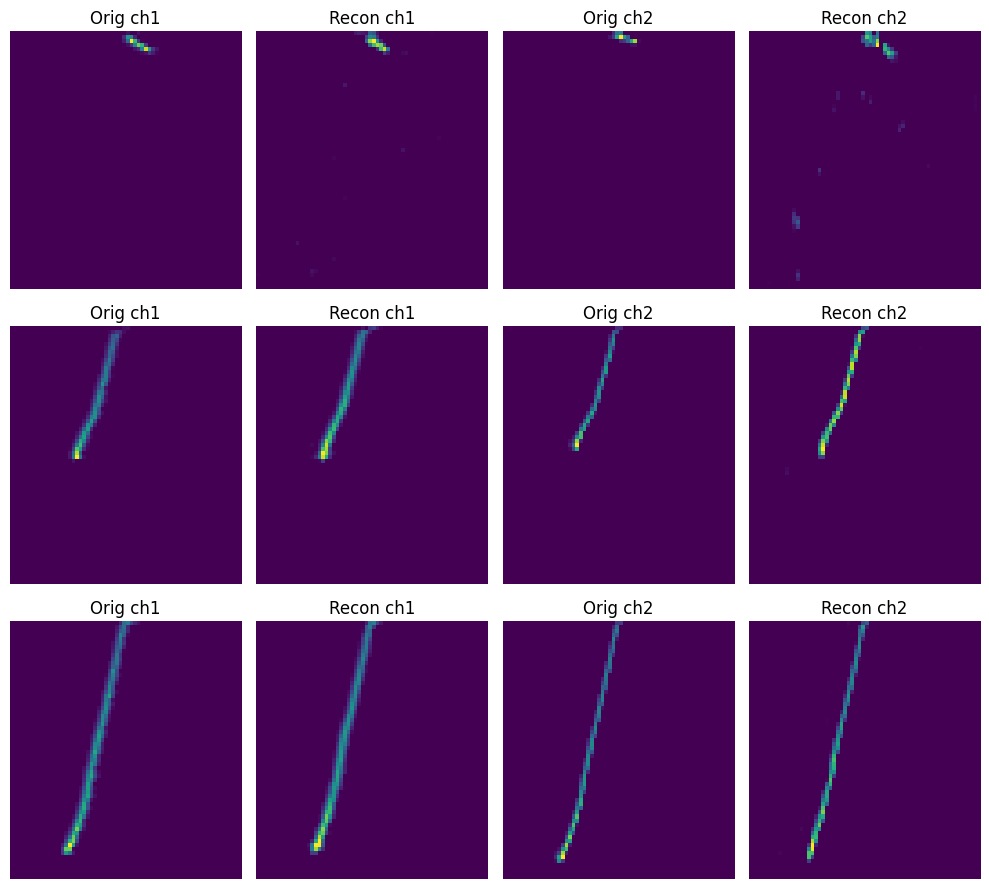

In [340]:
device_inf = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model.eval()
model.to(device_inf)

Xd_np = d.cpu().numpy() if torch.is_tensor(d) else np.array(d, dtype=np.float32)          # (N, H, W)
N, C, H, W = Xd_np.shape
batch_size = 8                           # lower if OOM on MPS

recon_all_d = np.empty((N, C, H, W), dtype=np.float32)
latent_dim = model.fc_enc.out_features
latent_vectors_d = np.empty((N, latent_dim), dtype=np.float32)

with torch.no_grad():
    for i in range(0, N, batch_size):
        j = min(i + batch_size, N)
        xb = torch.tensor(Xd_np[i:j], dtype=torch.float32).to(device_inf)  # (b,H,W)

        out = model(xb)                         # (b,H,W)
        recon_all_d[i:j] = out.cpu().numpy()

        enc = model.encoder(xb)    # (b,C,h_enc,w_enc)
        z_flat = enc.flatten(1)                 # (b,flat_size)
        z = model.fc_enc(z_flat)                # (b,latent)
        latent_vectors_d[i:j] = z.cpu().numpy()

        if device_inf.type == "mps":
            try:
                torch.mps.empty_cache()
            except Exception:
                pass

RE_per_sample_d = ((recon_all_d - Xd_np) ** 2).mean(axis=(1, 2, 3))

print("recon_all_d.shape:", recon_all_d.shape)
print("latent_vectors.shape:", latent_vectors_d.shape)
print("RE_per_sample_d.shape:", RE_per_sample_d.shape)

k = min(3, N)  # number of samples to show
fig, axs = plt.subplots(k, 4, figsize=(10, 3*k))  # 2 channels × (orig,recon)

for ii in range(k):
    for c in range(2):
        axs[ii, 2*c].imshow(Xd_np[ii, c], cmap='viridis', aspect='auto')
        axs[ii, 2*c].set_title(f"Orig ch{c+1}")
        axs[ii, 2*c].axis('off')

        axs[ii, 2*c+1].imshow(recon_all_d[ii, c], cmap='viridis', aspect='auto')
        axs[ii, 2*c+1].set_title(f"Recon ch{c+1}")
        axs[ii, 2*c+1].axis('off')

plt.tight_layout()
plt.show()


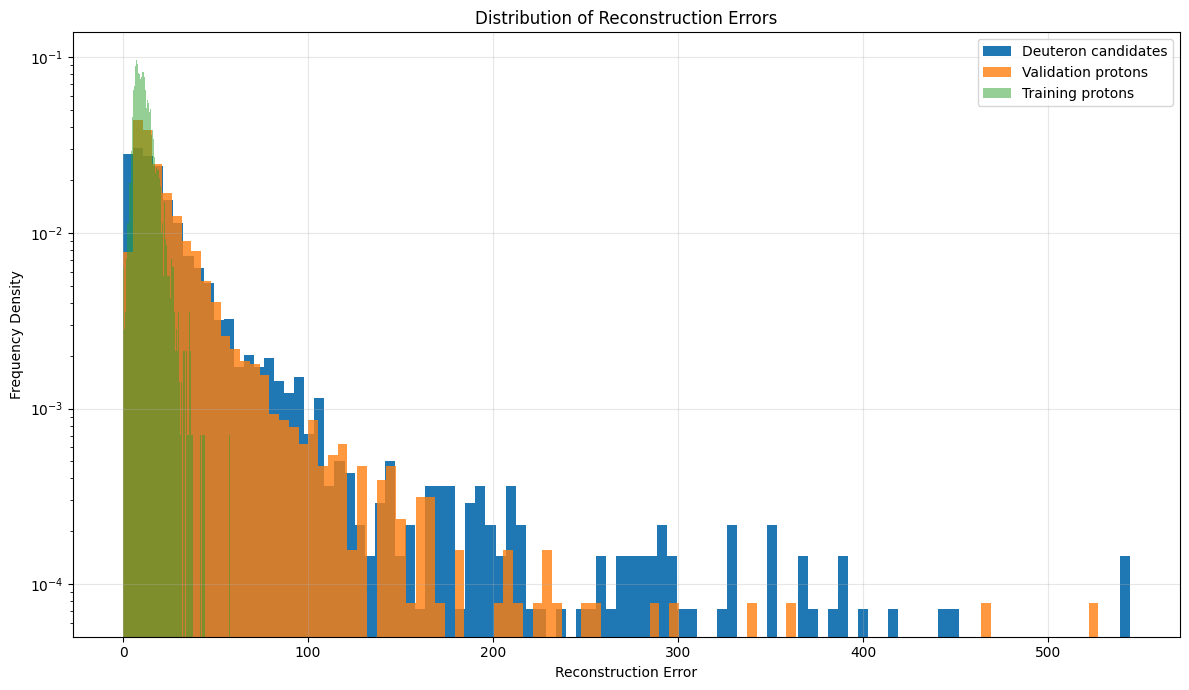

In [341]:
plt.figure(figsize=(12, 7))

plt.hist(RE_per_sample_d, bins=100, alpha=1, label='Deuteron candidates', density=True)
plt.hist(RE_per_sample_val, bins=100, alpha=0.8, label='Validation protons', density=True)
plt.hist(RE_per_sample, bins=100, alpha=0.5, label='Training protons', density=True)

plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency Density")
plt.title("Distribution of Reconstruction Errors")
plt.grid(True, alpha=0.3)
plt.yscale('log')
# plt.xlim(0, 300)
plt.legend()
plt.tight_layout()
plt.show()

Found 1424 samples


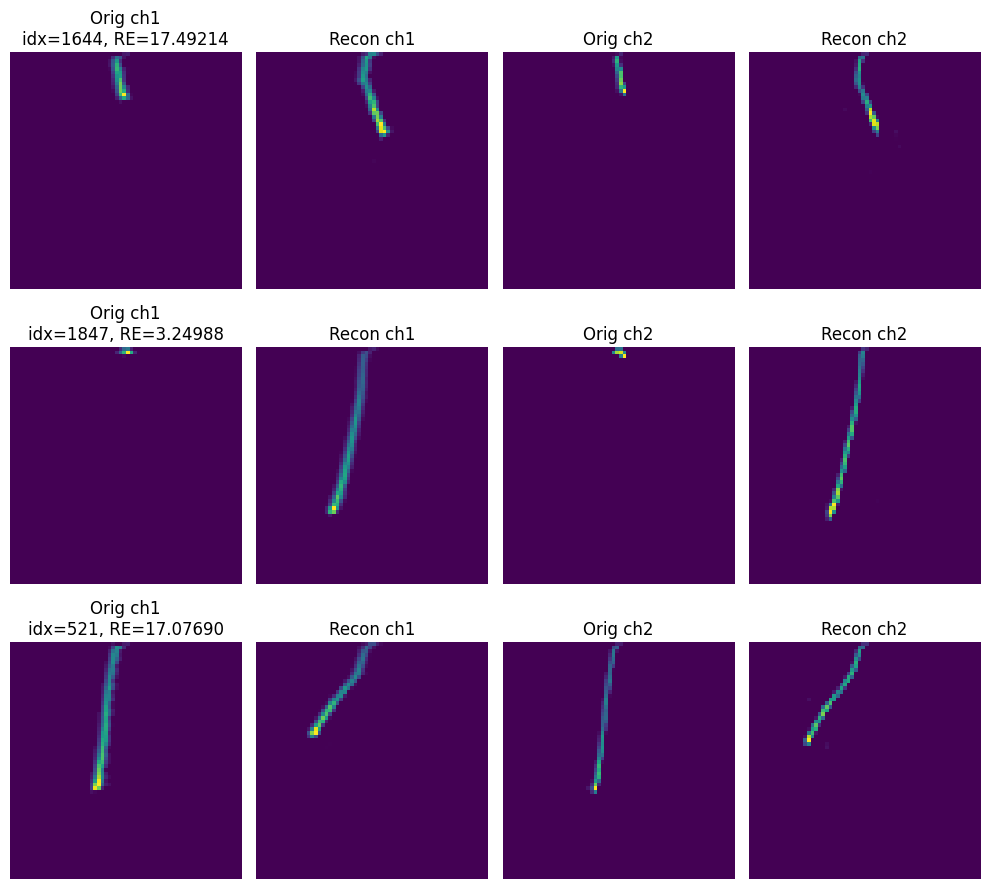

In [342]:
high_re_idx = np.where((RE_per_sample_d > 0) & (RE_per_sample_d < 20))[0]
print(f"Found {len(high_re_idx)} samples")

k = min(3, len(high_re_idx))
if k == 0:
    print("No samples found in specified RE range.")
else:
    selected = np.random.choice(high_re_idx, size=k, replace=False)

    # 4 columns: orig ch1 | recon ch1 | orig ch2 | recon ch2
    fig, axs = plt.subplots(k, 4, figsize=(10, 3*k))

    for ii in range(k):
        idx = selected[ii]

        # --- Channel 1 ---
        axs[ii, 0].imshow(Xd_np[idx, 0], cmap='viridis', aspect='auto')
        axs[ii, 0].set_title(f"Orig ch1\nidx={idx}, RE={RE_per_sample_d[idx]:.5f}")
        axs[ii, 0].axis('off')

        axs[ii, 1].imshow(recon_all[idx, 0], cmap='viridis', aspect='auto')
        axs[ii, 1].set_title("Recon ch1")
        axs[ii, 1].axis('off')

        # --- Channel 2 ---
        axs[ii, 2].imshow(Xd_np[idx, 1], cmap='viridis', aspect='auto')
        axs[ii, 2].set_title("Orig ch2")
        axs[ii, 2].axis('off')

        axs[ii, 3].imshow(recon_all[idx, 1], cmap='viridis', aspect='auto')
        axs[ii, 3].set_title("Recon ch2")
        axs[ii, 3].axis('off')

    plt.tight_layout()
    plt.show()


In [343]:
latent_vectors_d.shape, RE_per_sample_d.shape, recon_all_d.shape

((2553, 16), (2553,), (2553, 2, 64, 64))

In [344]:
latent_vectors.shape, RE_per_sample.shape, recon_all.shape

((2434, 16), (2434,), (2434, 2, 64, 64))

In [345]:
latent_vectors_val.shape, RE_per_sample_val.shape, recon_all_val.shape

((2433, 16), (2433,), (2433, 2, 64, 64))

In [346]:
from sklearn.manifold import TSNE

Z_all = np.concatenate([latent_vectors, latent_vectors_d, latent_vectors_val], axis=0)
labels = np.concatenate([
    np.zeros(len(latent_vectors)),          # 0 = protons
    np.ones(len(latent_vectors_d)),         # 1 = deuterons
    np.full(len(latent_vectors_val), 2)     # 2 = validation
])

In [347]:
tsne = TSNE(
    n_components=2,
    perplexity=50,
    learning_rate=50,
    max_iter=2000,
    init='random',
    random_state=42
)
Z_2d = tsne.fit_transform(Z_all)

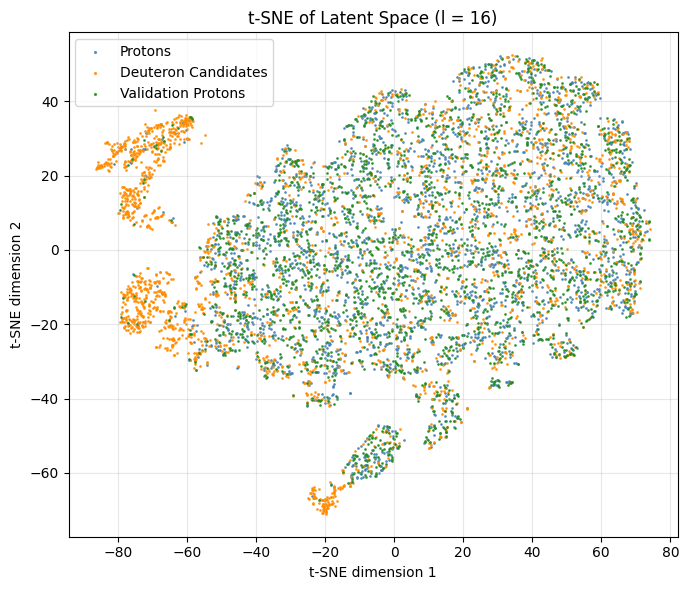

In [348]:
plt.figure(figsize=(7, 6))
colours = ['steelblue', 'darkorange', 'forestgreen']
labels_text = ['Protons', 'Deuteron Candidates', 'Validation Protons']

for i, (colour, label_name) in enumerate(zip(colours, labels_text)):
    plt.scatter(Z_2d[labels == i, 0],
                Z_2d[labels == i, 1],
                color=colour,
                alpha=0.8,
                s=1,
                label=label_name)

plt.xlabel("t-SNE dimension 1")
plt.ylabel("t-SNE dimension 2")
plt.legend(markerscale=1.3)
plt.title("t-SNE of Latent Space (l = 16)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

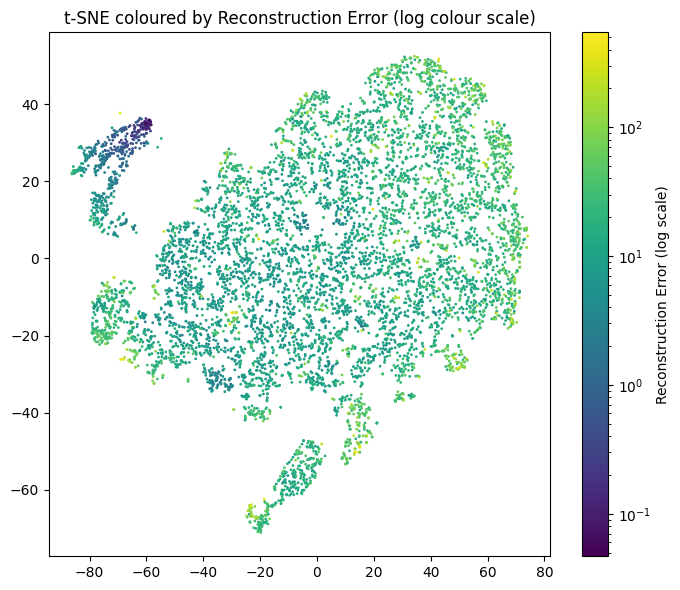

In [349]:
import matplotlib.colors as mcolors

Z_all = np.concatenate([latent_vectors, latent_vectors_d, latent_vectors_val])
RE_all = np.concatenate([RE_per_sample, RE_per_sample_d, RE_per_sample_val])

plt.figure(figsize=(7,6))
sc = plt.scatter(Z_2d[:, 0], Z_2d[:, 1],
                 c=RE_all,
                 cmap='viridis',
                 norm=mcolors.LogNorm(vmin=RE_all.min()+1e-8, vmax=RE_all.max()),
                 s=1)
plt.colorbar(sc, label='Reconstruction Error (log scale)')
plt.title("t-SNE coloured by Reconstruction Error (log colour scale)")
plt.tight_layout()
plt.show()

# low error regions and high error regions in deuteron candidates?
# overlap with proton latent vectors?
# separation with proton latent vectors

In [350]:
import umap
reducer = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=42)
Z_umap = reducer.fit_transform(Z_all)

/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


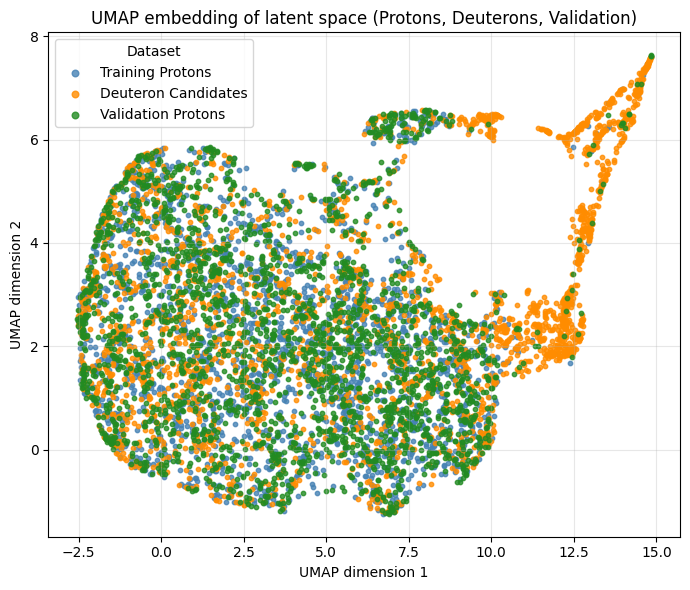

In [351]:
# labels: 0=Protons, 1=Deuterons, 2=Validation
palette = ['steelblue', 'darkorange', 'forestgreen']  # order matches labels

plt.figure(figsize=(7,6))
for i, name in enumerate(['Training Protons', 'Deuteron Candidates', 'Validation Protons']):
    m = (labels == i)
    plt.scatter(Z_umap[m, 0], Z_umap[m, 1],
                color=palette[i], s=10, alpha=0.8, label=name)

plt.xlabel("UMAP dimension 1")
plt.ylabel("UMAP dimension 2")
plt.title("UMAP embedding of latent space (Protons, Deuterons, Validation)")
plt.legend(title="Dataset", markerscale=1.5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


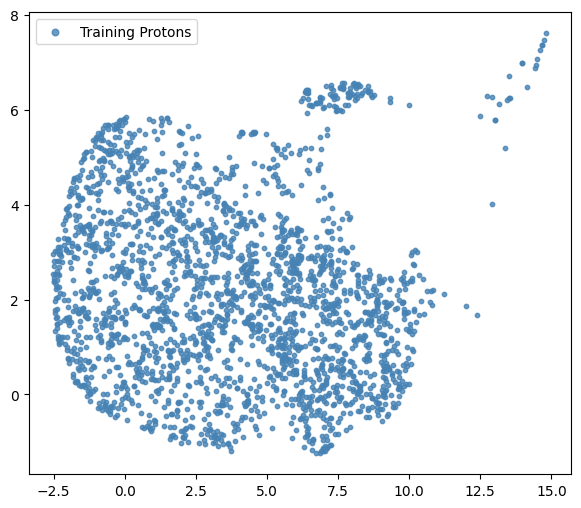

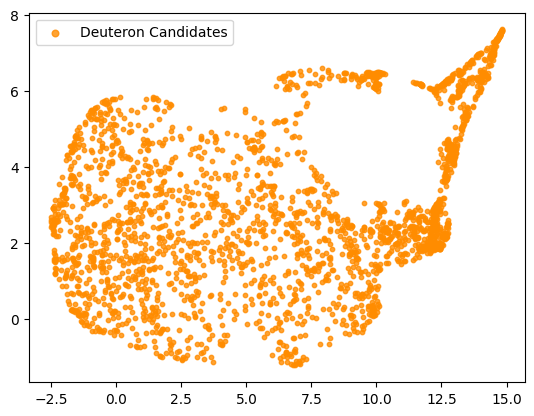

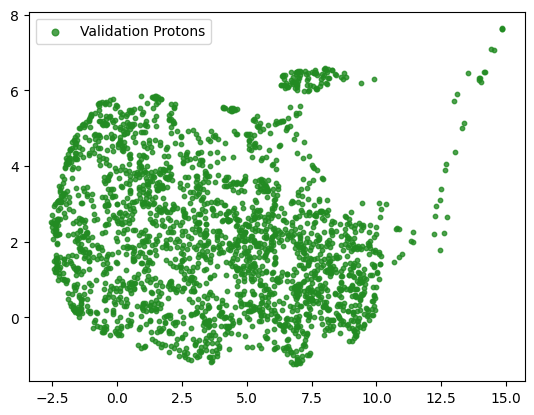

In [352]:
# labels: 0=Protons, 1=Deuterons, 2=Validation
palette = ['steelblue', 'darkorange', 'forestgreen']  # order matches labels

plt.figure(figsize=(7,6))
for i, name in enumerate(['Training Protons', 'Deuteron Candidates', 'Validation Protons']):
    m = (labels == i)
    plt.scatter(Z_umap[m, 0], Z_umap[m, 1],
                color=palette[i], s=10, alpha=0.8, label=name)
    plt.legend(markerscale=1.5)
    # plt.xlim(-5, 14)
    # plt.ylim(0, 10)
    plt.show()

# plt.xlabel("UMAP dimension 1")
# plt.ylabel("UMAP dimension 2")
# plt.title("UMAP embedding of latent space (Protons, Deuterons, Validation)")
# plt.legend(title="Dataset", markerscale=1.5)
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()


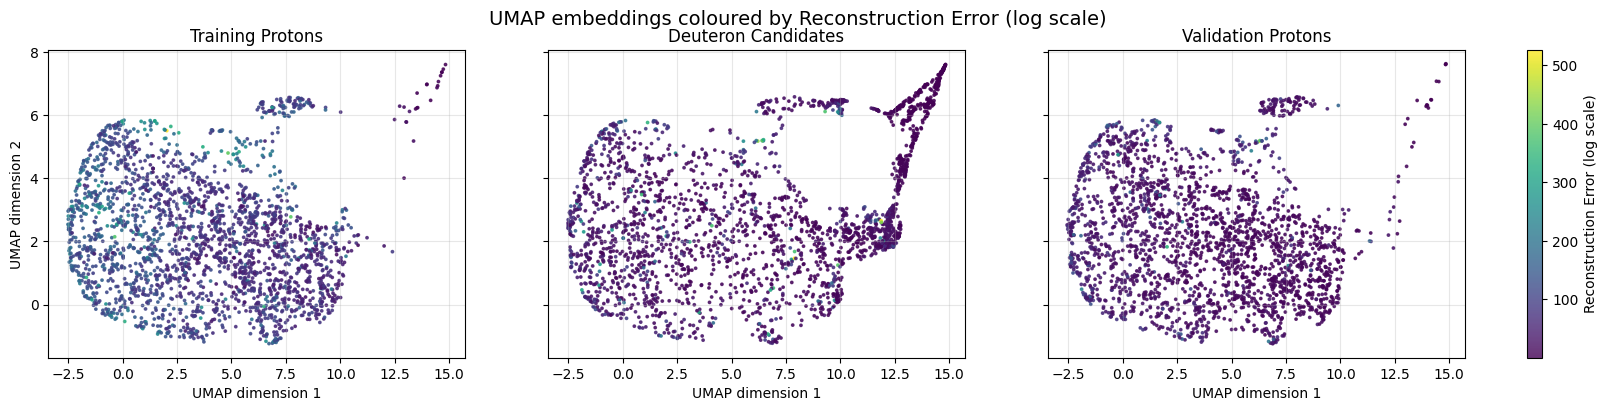

In [355]:
palette = ['steelblue', 'darkorange', 'forestgreen']
names = ['Training Protons', 'Deuteron Candidates', 'Validation Protons']

norm = mcolors.LogNorm(vmin=RE_all.min() + 1e-8, vmax=RE_all.max())
cmap = plt.cm.viridis

fig, axes = plt.subplots(1, 3, figsize=(20, 4), sharex=True, sharey=True)

for i, ax in enumerate(axes):
    m = (labels == i)
    sc = ax.scatter(
        Z_umap[m, 0],
        Z_umap[m, 1],
        c=RE_all[m],
        cmap=cmap,
        # norm=norm,
        s=3,
        alpha=0.8
    )
    ax.set_title(names[i], fontsize=12)
    ax.set_xlabel("UMAP dimension 1")
    if i == 0:
        ax.set_ylabel("UMAP dimension 2")
    ax.grid(True, alpha=0.3)

cbar = fig.colorbar(sc, ax=axes.ravel().tolist(), fraction=0.046, pad=0.04)
cbar.set_label('Reconstruction Error (log scale)')

fig.suptitle("UMAP embeddings coloured by Reconstruction Error (log scale)", fontsize=14)

plt.savefig('UMAPandRE.png', dpi=1000)
plt.show()


/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


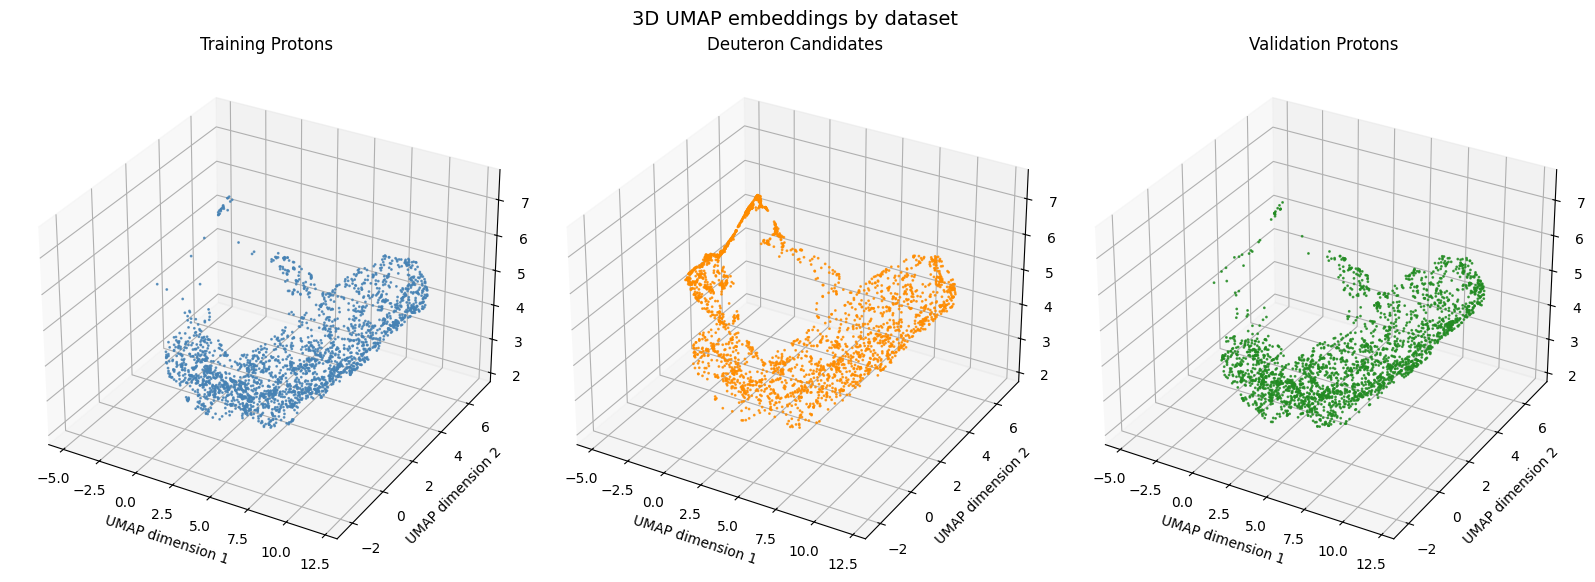

In [356]:
from mpl_toolkits.mplot3d import Axes3D

umap_3d = umap.UMAP(n_components=3, random_state=42)
embedding = umap_3d.fit_transform(Z_all)

palette = ['steelblue', 'darkorange', 'forestgreen']
names = ['Training Protons', 'Deuteron Candidates', 'Validation Protons']

fig = plt.figure(figsize=(16, 6))

for i, name in enumerate(names):
    mask = (labels == i)
    ax = fig.add_subplot(1, 3, i + 1, projection='3d')
    ax.scatter(
        embedding[mask, 0],
        embedding[mask, 1],
        embedding[mask, 2],
        color=palette[i],
        s=1,
        alpha=0.8
    )
    ax.set_title(name)
    ax.set_xlabel("UMAP dimension 1")
    ax.set_ylabel("UMAP dimension 2")
    ax.set_zlabel("UMAP dimension 3")
    # ax.view_init(elev=25, azim=45)  

fig.suptitle("3D UMAP embeddings by dataset", fontsize=14)
plt.tight_layout()
plt.show()


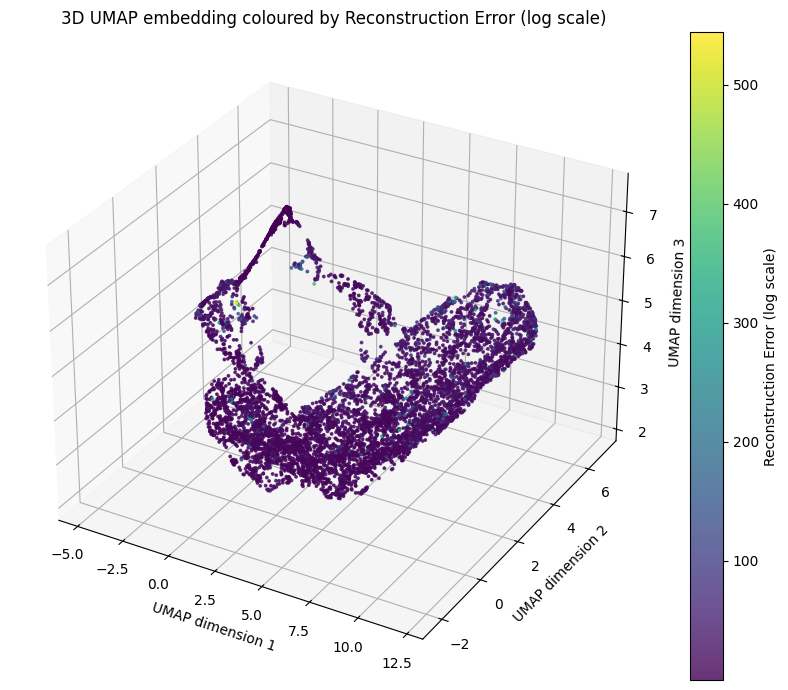

In [357]:
%matplotlib inline

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot coloured by reconstruction error
sc = ax.scatter(
    embedding[:, 0],
    embedding[:, 1],
    embedding[:, 2],
    c=RE_all,
    cmap='viridis',
    # norm=mcolors.LogNorm(vmin=RE_all.min() + 1e-8, vmax=RE_all.max()),
    s=3,
    alpha=0.8
)

# Axis labels and title
ax.set_xlabel("UMAP dimension 1")
ax.set_ylabel("UMAP dimension 2")
ax.set_zlabel("UMAP dimension 3")
ax.set_title("3D UMAP embedding coloured by Reconstruction Error (log scale)")

# Colour bar
cbar = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Reconstruction Error (log scale)')

plt.tight_layout()
plt.show()


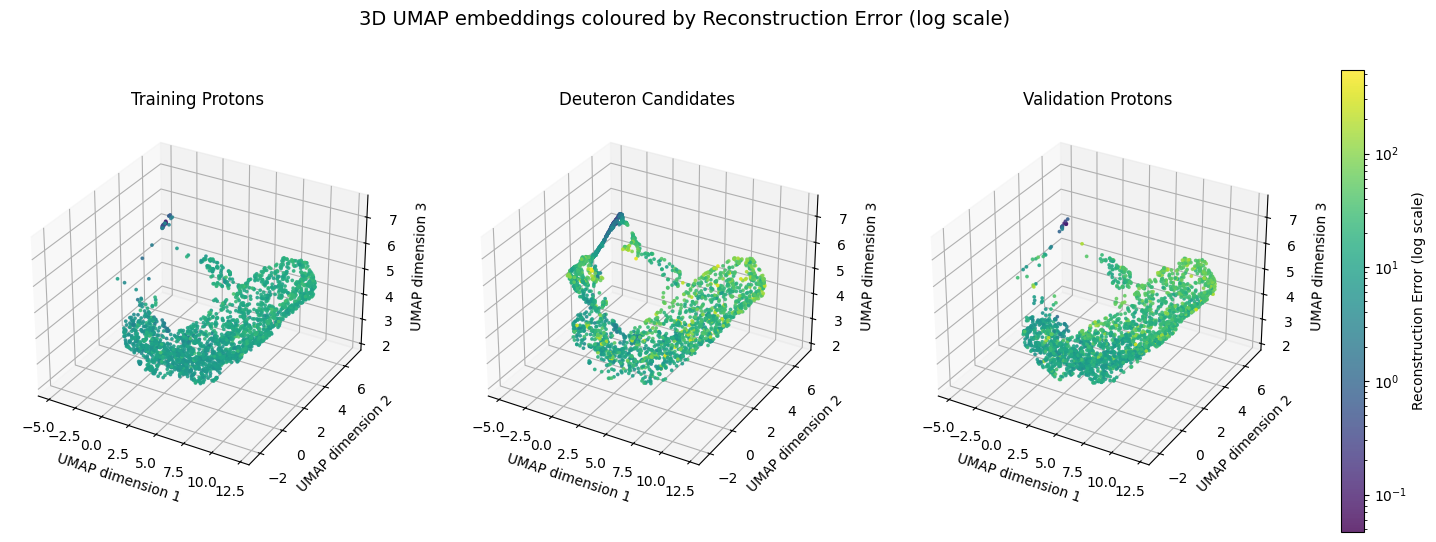

In [358]:
%matplotlib inline
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# Assume: embedding (3D UMAP), RE_all (reconstruction errors), labels (0,1,2)
palette = ['steelblue', 'darkorange', 'forestgreen']
names = ['Training Protons', 'Deuteron Candidates', 'Validation Protons']

# Shared normalisation and colormap for all plots
norm = mcolors.LogNorm(vmin=RE_all.min() + 1e-8, vmax=RE_all.max())
cmap = plt.cm.viridis

fig = plt.figure(figsize=(18, 6))

for i, name in enumerate(names):
    mask = (labels == i)
    ax = fig.add_subplot(1, 3, i + 1, projection='3d')

    sc = ax.scatter(
        embedding[mask, 0],
        embedding[mask, 1],
        embedding[mask, 2],
        c=RE_all[mask],
        cmap=cmap,
        norm=norm,
        s=3,
        alpha=0.8
    )

    ax.set_title(name, fontsize=12)
    ax.set_xlabel("UMAP dimension 1")
    ax.set_ylabel("UMAP dimension 2")
    ax.set_zlabel("UMAP dimension 3")
    # ax.view_init(elev=25, azim=45)  # consistent 3D orientation

# Shared colour bar for all subplots
cbar = fig.colorbar(sc, ax=fig.get_axes(), fraction=0.046, pad=0.04)
cbar.set_label('Reconstruction Error (log scale)')

fig.suptitle("3D UMAP embeddings coloured by Reconstruction Error (log scale)", fontsize=14)
plt.show()


In [359]:
latent_vectors.shape, latent_vectors_val.shape, latent_vectors_d.shape

((2434, 16), (2433, 16), (2553, 16))

In [360]:
latent = np.concatenate([latent_vectors, latent_vectors_val])

Deuteron subset shape: (2553, 2)


/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-pac

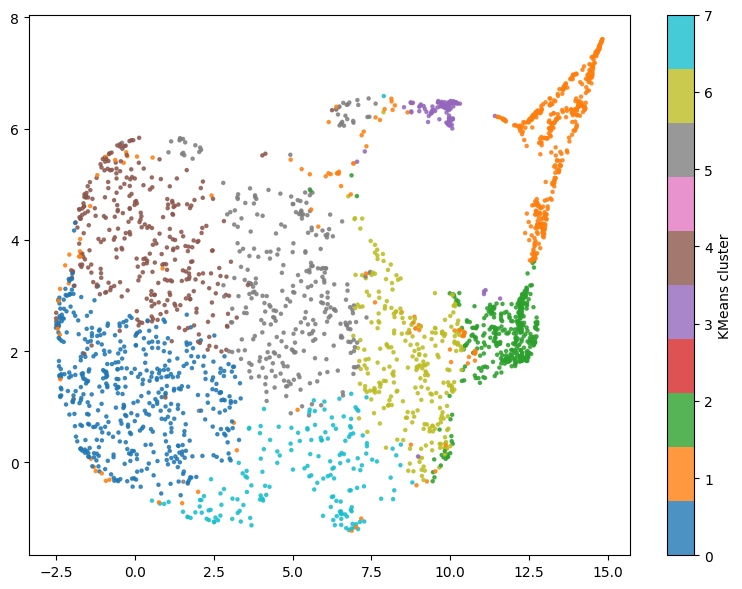

In [644]:
from sklearn.cluster import KMeans

Z_all = np.concatenate([latent_vectors, latent_vectors_d, latent_vectors_val], axis=0)
labels = np.concatenate([
    np.zeros(len(latent_vectors)),          # 0 = protons
    np.ones(len(latent_vectors_d)),         # 1 = deuterons
    np.full(len(latent_vectors_val), 2)     # 2 = validation
])

mask = (labels == 1)
Z_d = Z_all[mask]          # latent vectors
E_d = Z_umap[mask]      # 3D UMAP coordinates

print(f"Deuteron subset shape: {E_d.shape}")

kmeans = KMeans(n_clusters=8, random_state=42) #6
labels_km = kmeans.fit_predict(Z_d)

fig = plt.figure(figsize=(8, 6))
sc = plt.scatter(E_d[:, 0], E_d[:, 1],
                c=labels_km, cmap='tab10', s=5, alpha=0.8)
plt.colorbar(label='KMeans cluster')
ax.set_title("Deuteron candidates — KMeans clusters")
ax.set_xlabel("UMAP dim 1")
ax.set_ylabel("UMAP dim 2")
plt.tight_layout()
plt.show()


In [617]:
p_m = col[col['particle_type'] == 'proton']['beamline_mass'].values
d_m = col[col['particle_type'] == 'deuteron']['beamline_mass'].values

d_l = col[col['particle_type'] == 'deuteron']['height'].values
d_p = col[col['particle_type'] == 'deuteron']['p'].values

d_diff = col[col['particle_type'] == 'deuteron']['maxdiff'].values
p_diff = col[col['particle_type'] == 'proton']['maxdiff'].values

d_mean_diff = col[col['particle_type'] == 'deuteron']['meandiff'].values
p_mean_diff = col[col['particle_type'] == 'proton']['meandiff'].values

labels = labels_km

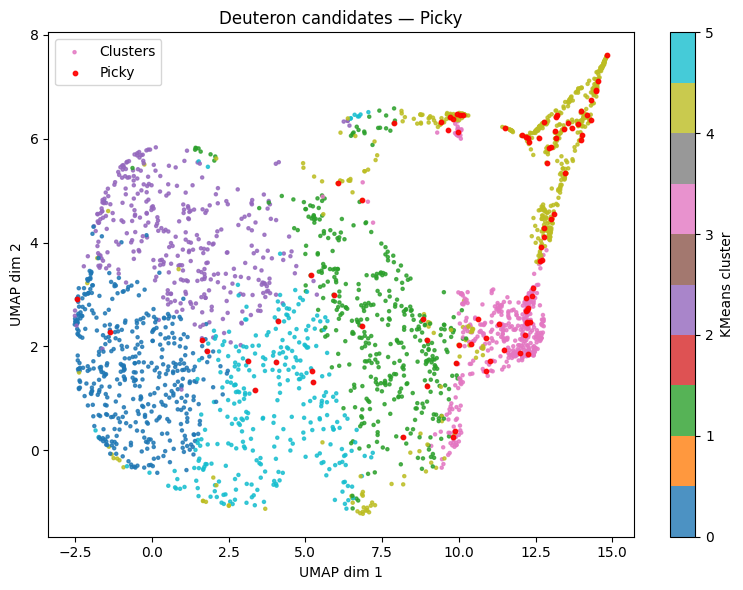

In [618]:
# Highlight points where highlight == 1
highlight_mask = (d_p == 1)

fig = plt.figure(figsize=(8, 6))
sc = plt.scatter(E_d[:, 0], E_d[:, 1], c=labels_km, cmap='tab10', s=5, alpha=0.8, label='Clusters')

# Overlay highlighted points
plt.scatter(E_d[highlight_mask, 0], E_d[highlight_mask, 1], 
            color='red', s=10, label='Picky', alpha=0.9)

plt.colorbar(sc, label='KMeans cluster')
plt.title("Deuteron candidates — Picky")
plt.xlabel("UMAP dim 1")
plt.ylabel("UMAP dim 2")
plt.legend()
plt.tight_layout()
plt.show()

/var/folders/cm/m55y72dj6cd5lkwrfdb2bpnr0000gp/T/ipykernel_43150/3195687694.py:9: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = plt.scatter(m[:, 0], m[:, 1], cmap='tab10', s=5, alpha=0.8, label='Clusters')


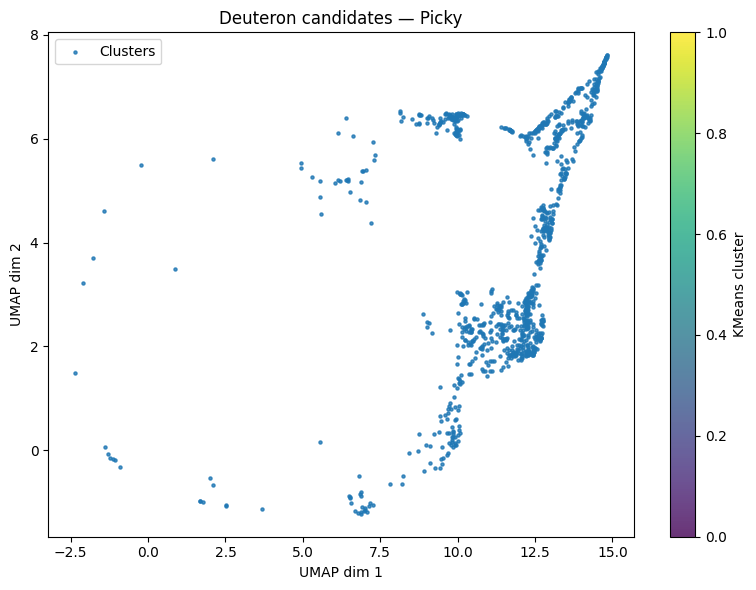

In [641]:
m0 = E_d[(labels == 3) & (d_p)]
m1 = E_d[(labels == 4)]
m = np.concatenate([m0, m1])

# Highlight points where highlight == 1
highlight_mask = (d_p == 1)

fig = plt.figure(figsize=(8, 6))
sc = plt.scatter(m[:, 0], m[:, 1], cmap='tab10', s=5, alpha=0.8, label='Clusters')

# Overlay highlighted points
plt.scatter(m[highlight_mask, 0], m[highlight_mask, 1], 
            color='red', s=10, label='Picky', alpha=0.9)

plt.colorbar(sc, label='KMeans cluster')
plt.title("Deuteron candidates — Picky")
plt.xlabel("UMAP dim 1")
plt.ylabel("UMAP dim 2")
plt.legend()
plt.tight_layout()
plt.show()

In [619]:
unique, counts = np.unique(highlight_mask, return_counts=True)

unique, counts

(array([False,  True]), array([2466,   87]))

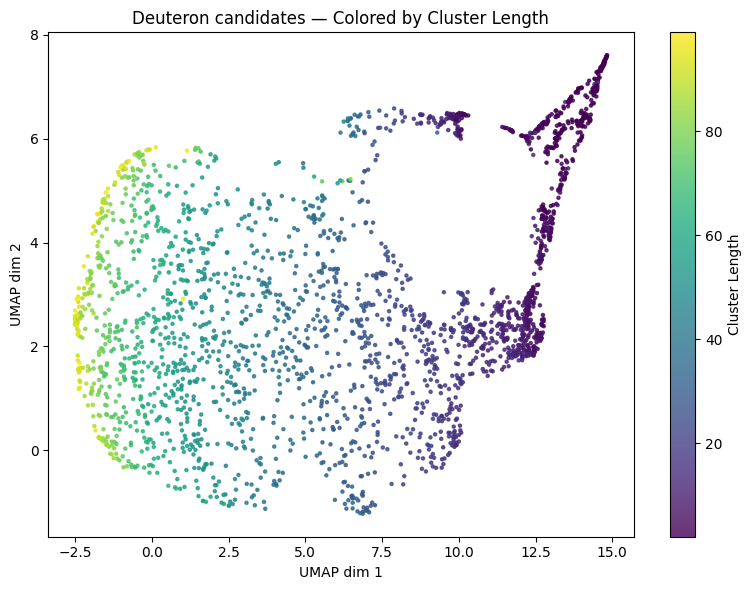

In [620]:
fig = plt.figure(figsize=(8, 6))

# Scatter plot colored by cluster length
sc = plt.scatter(E_d[:, 0], E_d[:, 1],
                 c=d_l, cmap='viridis', s=5, alpha=0.8)

# Add a colorbar to indicate cluster length
cbar = plt.colorbar(sc)
cbar.set_label("Cluster Length")

plt.title("Deuteron candidates — Colored by Cluster Length")
plt.xlabel("UMAP dim 1")
plt.ylabel("UMAP dim 2")
plt.tight_layout()
plt.show()

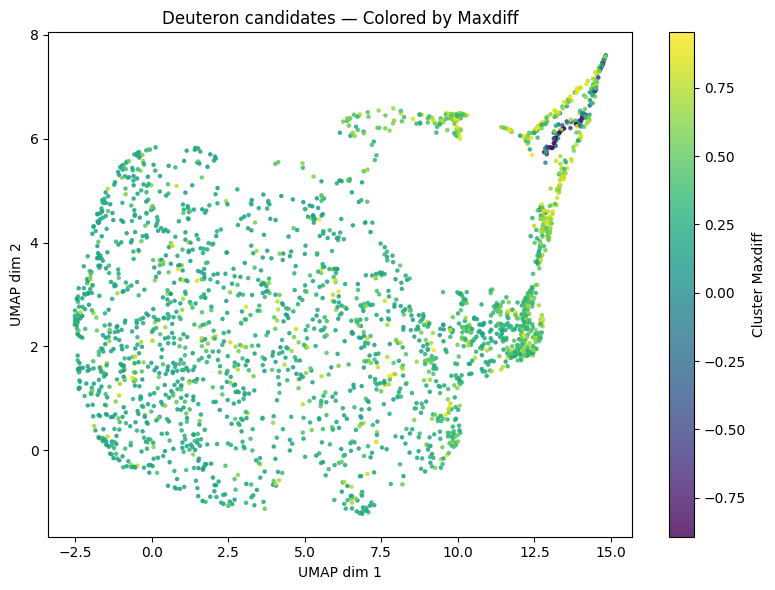

In [621]:
fig = plt.figure(figsize=(8, 6))

# Scatter plot colored by cluster length
sc = plt.scatter(E_d[:, 0], E_d[:, 1],
                 c=d_diff, cmap='viridis', s=5, alpha=0.8)

# Add a colorbar to indicate cluster length
cbar = plt.colorbar(sc)
cbar.set_label("Cluster Maxdiff")

plt.title("Deuteron candidates — Colored by Maxdiff")
plt.xlabel("UMAP dim 1")
plt.ylabel("UMAP dim 2")
plt.tight_layout()
plt.show()

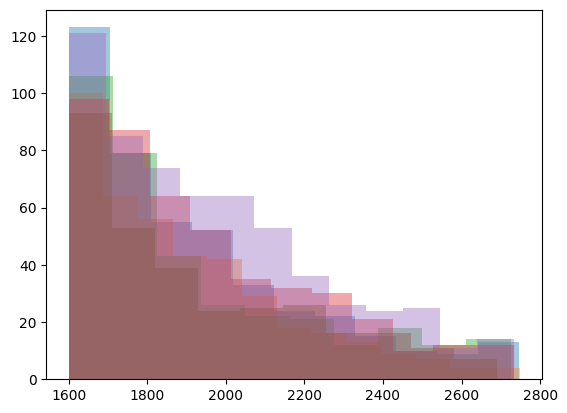

In [623]:
for i in range(6):
    mass = d_m[labels == i]
    plt.hist(mass, bins='auto', alpha=0.4, label=f'Label {i}')

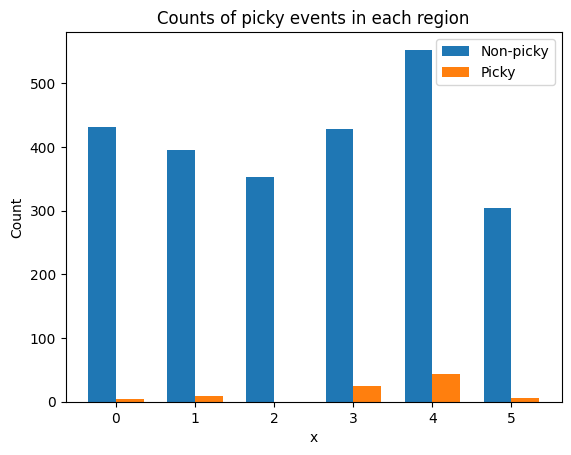

In [624]:
k = 6
counts = np.zeros((k, 2))  # rows: x, cols: label
for i in range(k):
    for j in [0, 1]:
        counts[i, j] = np.sum((labels == i) & (d_p == j))

x_vals = np.arange(k)  # positions for x = 0, 1
width = 0.35

plt.bar(x_vals - width/2, counts[:, 0], width, label='Non-picky', color='tab:blue')
plt.bar(x_vals + width/2, counts[:, 1], width, label='Picky', color='tab:orange')

# plt.xticks(x_vals, ['x=0', 'x=1', 'x=2', 'x=3'])
plt.ylabel('Count')
plt.xlabel('x')
plt.legend()
plt.title('Counts of picky events in each region')
plt.show()


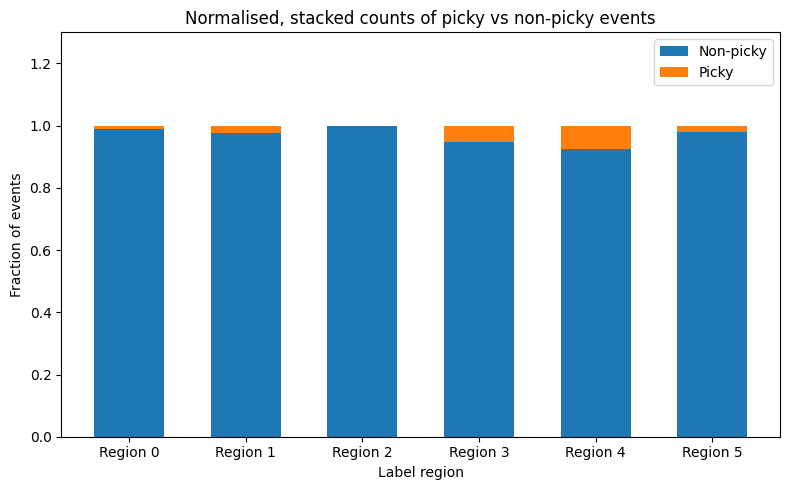

In [625]:
k = 6
counts = np.zeros((k, 2))  # rows: label (0–5), cols: [non-picky, picky]

for i in range(k):
    for j in [0, 1]:
        counts[i, j] = np.sum((labels == i) & (d_p == j))

# Normalise per label
row_sums = counts.sum(axis=1, keepdims=True)
counts_norm = np.divide(counts, row_sums, where=row_sums != 0)  # avoid divide-by-zero

x_vals = np.arange(k)
width = 0.6

plt.figure(figsize=(8, 5))
plt.bar(x_vals, counts_norm[:, 0], width, label='Non-picky', color='tab:blue')
plt.bar(x_vals, counts_norm[:, 1], width, bottom=counts_norm[:, 0],
        label='Picky', color='tab:orange')

plt.ylabel('Fraction of events')
plt.xlabel('Label region')
plt.title('Normalised, stacked counts of picky vs non-picky events')
plt.xticks(x_vals, [f'Region {i}' for i in range(k)])
plt.ylim(0, 1.3)
plt.legend()
plt.tight_layout()
plt.show()


In [626]:
# look at mass plot of just the picky

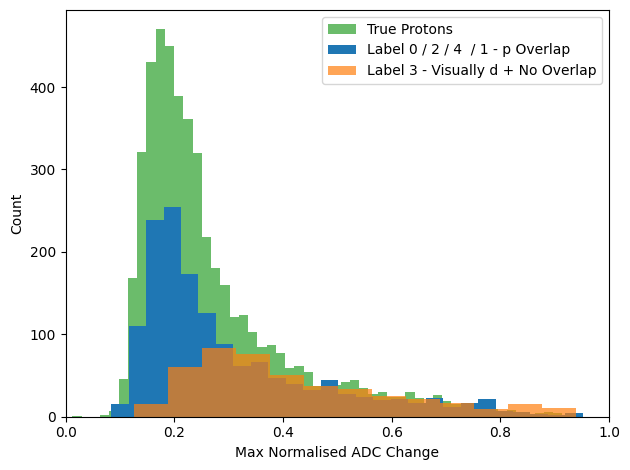

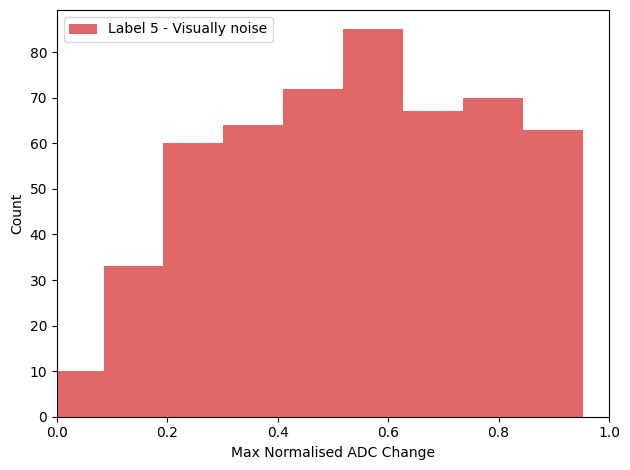

In [627]:
mass_0 = d_diff[(labels == 0) | (labels == 2) | (labels == 5) | (labels == 1) ]
mass_1 = d_diff[(labels == 3)]
mass_2 = d_diff[(labels == 4)]
mass_3 = p_diff

# Plot
plt.hist(mass_3, bins='auto', alpha=0.7, label='True Protons', color='tab:green')
plt.hist(mass_0, bins='auto', alpha=1.0, label='Label 0 / 2 / 4  / 1 - p Overlap', color='tab:blue')
plt.hist(mass_1, bins='auto', alpha=0.7, label='Label 3 - Visually d + No Overlap', color='tab:orange')
plt.xlim(0, 1)
plt.xlabel('Max Normalised ADC Change')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

plt.hist(mass_2, bins='auto', alpha=0.7, label='Label 5 - Visually noise', color='tab:red')


# plt.axvline(1875.6, c='red', linestyle=':', linewidth=2, label='Deuteron Mass')

plt.xlim(0, 1)
plt.xlabel('Max Normalised ADC Change')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()+


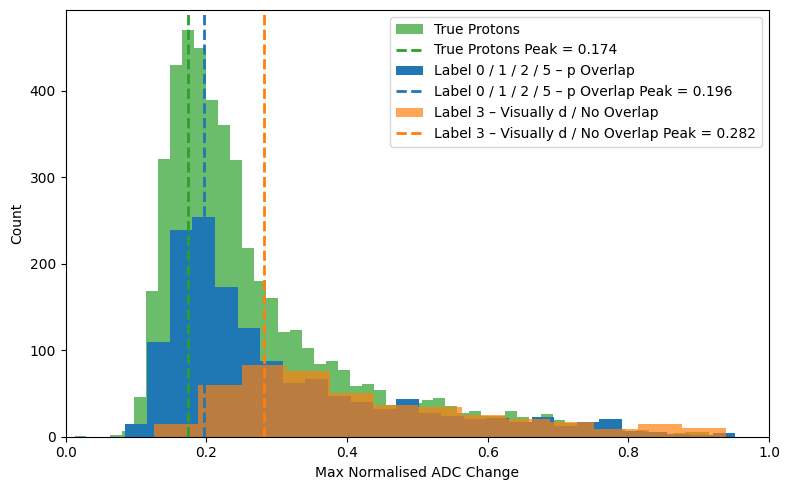

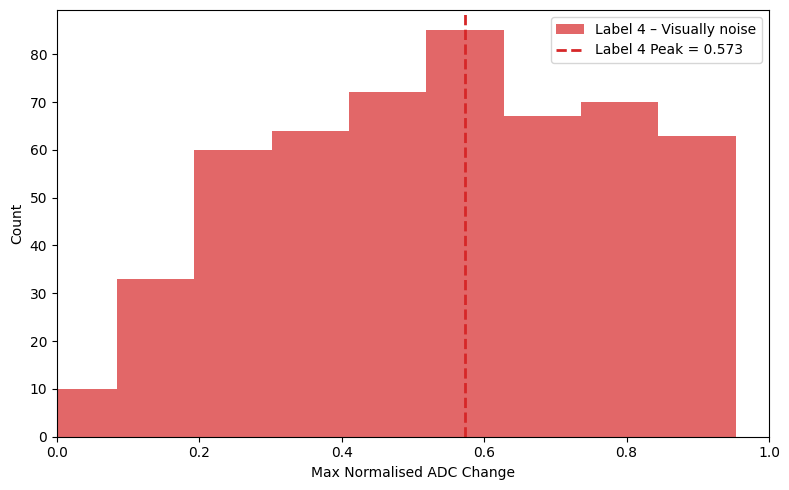

In [628]:
mass_0 = d_diff[(labels == 0) | (labels == 1) | (labels == 2) | (labels == 5)]
mass_1 = d_diff[(labels == 3)]
mass_2 = d_diff[(labels == 4)]
mass_3 = p_diff

plt.figure(figsize=(8, 5))

datasets = [
    (mass_3, 'True Protons', 'tab:green', 0.7),
    (mass_0, 'Label 0 / 1 / 2 / 5 – p Overlap', 'tab:blue', 1.0),
    (mass_1, 'Label 3 – Visually d / No Overlap', 'tab:orange', 0.7),
]

for data, label, colour, alpha in datasets:
    counts, bins, _ = plt.hist(data, bins='auto', alpha=alpha, label=label, color=colour)
    max_bin_idx = np.argmax(counts)
    peak_x = 0.5 * (bins[max_bin_idx] + bins[max_bin_idx + 1])
    plt.axvline(peak_x, color=colour, linestyle='--', linewidth=2,
                label=f'{label} Peak = {peak_x:.3f}')

plt.xlim(0, 1)
plt.xlabel('Max Normalised ADC Change')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
counts, bins, _ = plt.hist(mass_2, bins='auto', alpha=0.7, label='Label 4 – Visually noise', color='tab:red')
max_bin_idx = np.argmax(counts)
peak_x = 0.5 * (bins[max_bin_idx] + bins[max_bin_idx + 1])
plt.axvline(peak_x, color='tab:red', linestyle='--', linewidth=2,
            label=f'Label 4 Peak = {peak_x:.3f}')

plt.xlim(0, 1)
plt.xlabel('Max Normalised ADC Change')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()


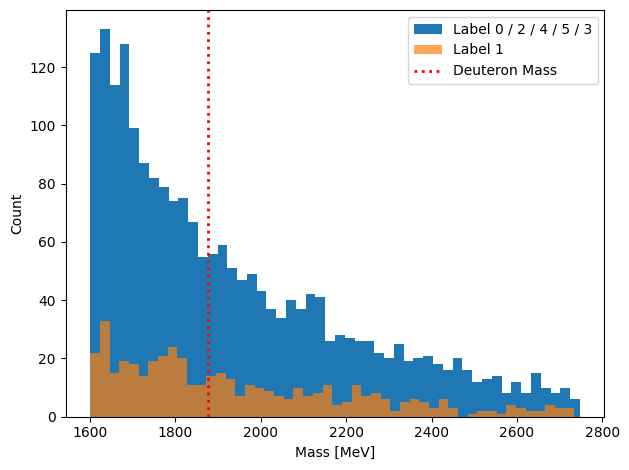

In [629]:
mass_0 = d_m[(labels == 0) | (labels == 2) | (labels == 4) | (labels == 5) | (labels == 1) ]
mass_1 = d_m[(labels == 3)]

# Plot
plt.hist(mass_0, bins=50, alpha=1.0, label='Label 0 / 2 / 4 / 5 / 3', color='tab:blue')
plt.hist(mass_1, bins=50, alpha=0.7, label='Label 1', color='tab:orange')
plt.axvline(1875.6, c='red', linestyle=':', linewidth=2, label='Deuteron Mass')

plt.xlabel('Mass [MeV]')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

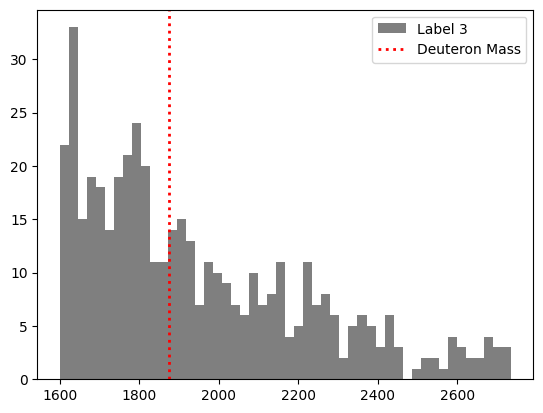

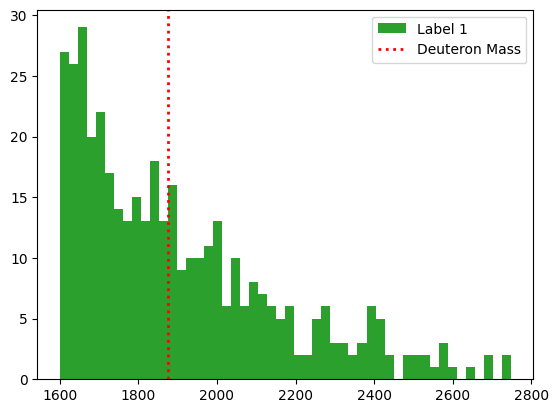

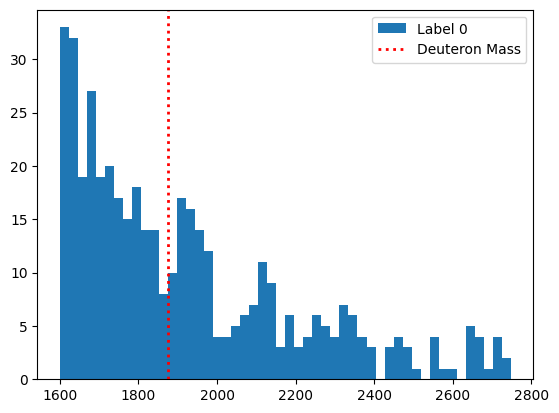

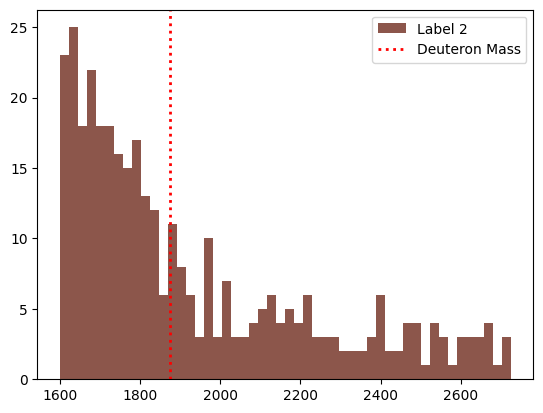

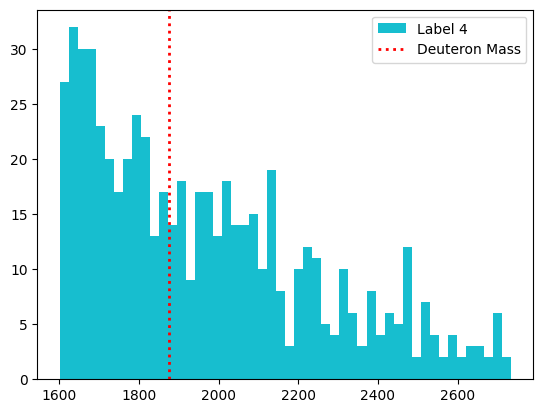

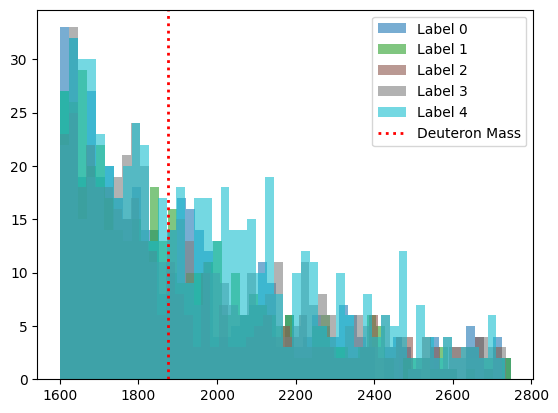

In [630]:
labels = labels_km

m0 = d_m[(labels == 0)]
m1 = d_m[(labels == 1)]
m2 = d_m[(labels == 2)]
m3 = d_m[(labels == 3)]
m4 = d_m[(labels == 4)]
m5 = d_m[(labels == 5)]


label_colours = {
    0: 'tab:blue',   
    1: 'tab:green',  
    2: 'tab:brown',  
    3: 'tab:gray',   
    4: 'tab:cyan'   
}

plt.hist(m3, bins=50, alpha=1, color=label_colours[3], label='Label 3')
plt.axvline(1875.6, c='red', linestyle=':', linewidth=2, label='Deuteron Mass')
plt.legend(); plt.show()

plt.hist(m1, bins=50, alpha=1, color=label_colours[1], label='Label 1')
plt.axvline(1875.6, c='red', linestyle=':', linewidth=2, label='Deuteron Mass')
plt.legend(); plt.show()

plt.hist(m0, bins=50, alpha=1, color=label_colours[0], label='Label 0')
plt.axvline(1875.6, c='red', linestyle=':', linewidth=2, label='Deuteron Mass')
plt.legend(); plt.show()

plt.hist(m2, bins=50, alpha=1, color=label_colours[2], label='Label 2')
plt.axvline(1875.6, c='red', linestyle=':', linewidth=2, label='Deuteron Mass')
plt.legend(); plt.show()

plt.hist(m4, bins=50, alpha=1, color=label_colours[4], label='Label 4')
plt.axvline(1875.6, c='red', linestyle=':', linewidth=2, label='Deuteron Mass')
plt.legend(); plt.show()

for i, m in enumerate([m0, m1, m2, m3, m4]):
    plt.hist(m, bins=50, alpha=0.6, color=label_colours[i], label=f'Label {i}')

plt.axvline(1875.6, c='red', linestyle=':', linewidth=2, label='Deuteron Mass')
plt.legend(); plt.show()


In [631]:
d_p.shape, d_m.shape, labels.shape

((2553,), (2553,), (2553,))

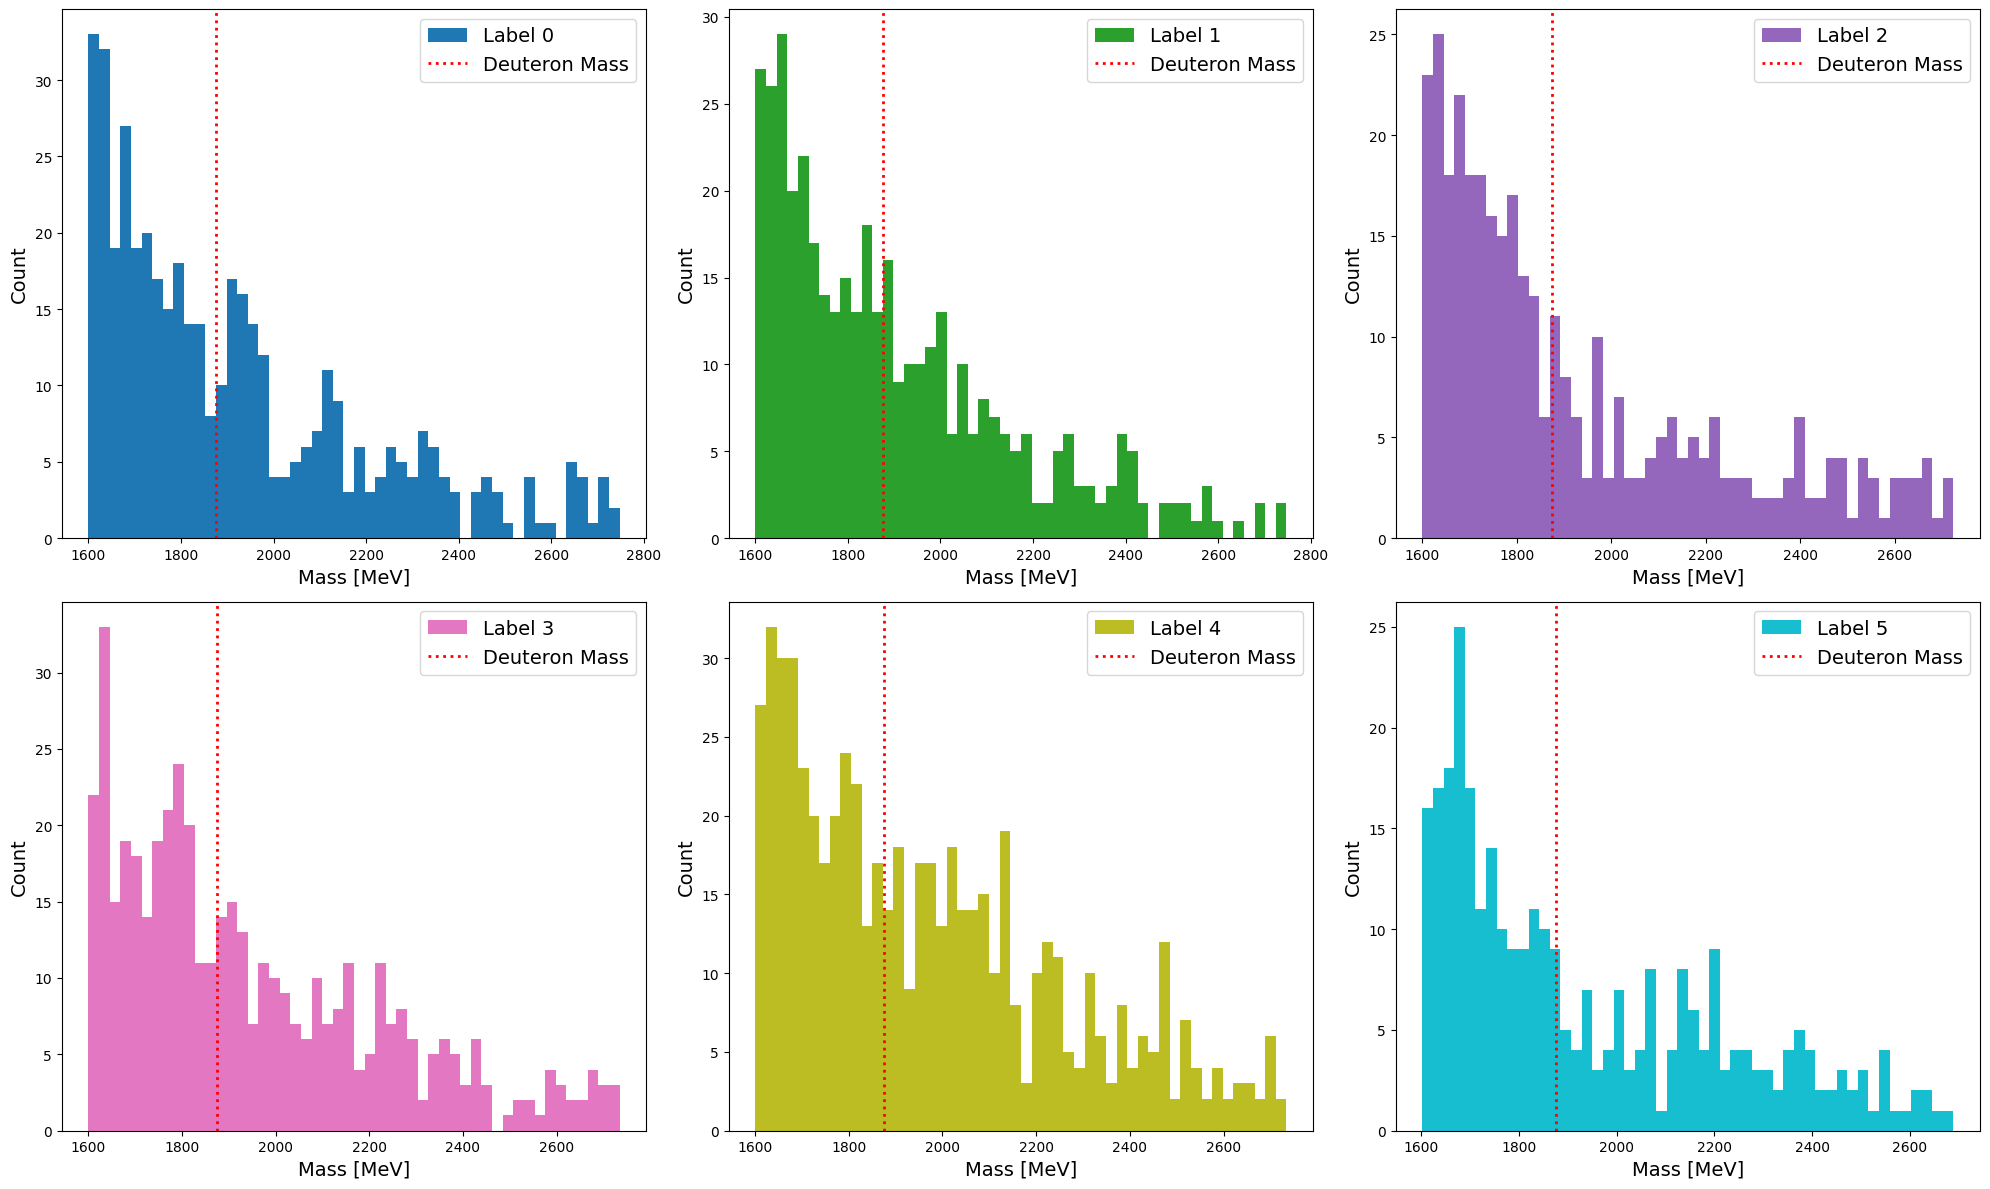

In [632]:
# Define consistent colours
label_colours = {
    0: 'tab:blue',
    1: 'tab:green',
    2: 'tab:purple',
    3: 'tab:pink',
    4: 'tab:olive',
    5: 'tab:cyan'
}

# Your datasets
datasets = {0: m0, 1: m1, 2: m2, 3: m3, 4: m4, 5:m5}

# Create a grid (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, label in enumerate(datasets.keys()):
    ax = axes[i]
    ax.hist(datasets[label], bins=50, alpha=1, color=label_colours[label], label=f'Label {label}')
    ax.axvline(1875.6, c='red', linestyle=':', linewidth=2, label='Deuteron Mass')
    ax.legend(fontsize=14)
    ax.set_xlabel('Mass [MeV]', fontsize=14)
    ax.set_ylabel('Count', fontsize=14)

# Hide any unused subplot (since we have 5 plots but 6 slots)
for j in range(len(datasets), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
# plt.savefig('labelsvmass.png', dpi=500)
plt.show()


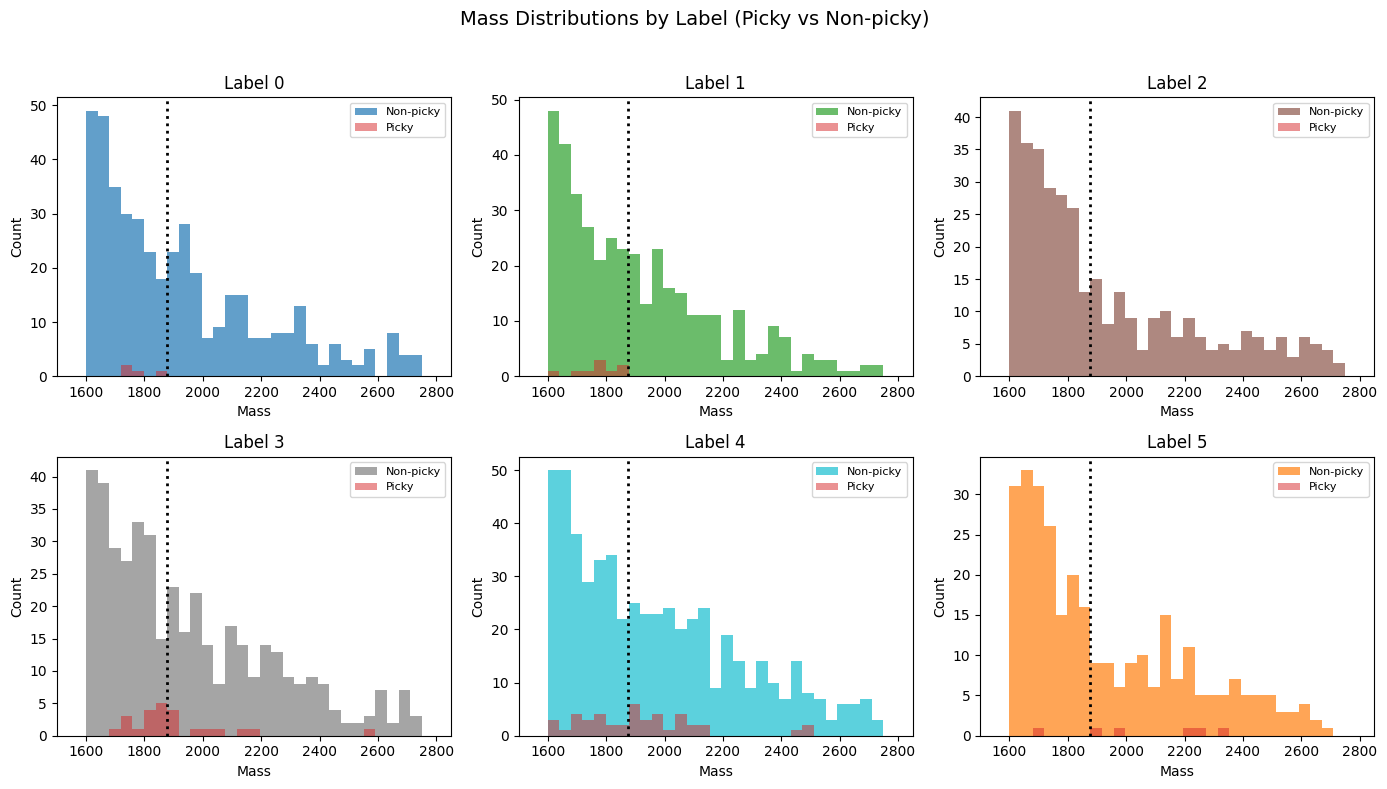

In [634]:
labels = labels_km

label_colours = {
    0: 'tab:blue',
    1: 'tab:green',
    2: 'tab:brown',
    3: 'tab:gray',
    4: 'tab:cyan',
    5: 'tab:orange'
}

unique_labels = np.unique(labels)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

bins = np.linspace(1600, 2750, 30)

for ax, lbl in zip(axes, unique_labels):
    mask = (labels == lbl)
    m_label = d_m[mask]
    m_label_picky = d_m[mask & (d_p == 1)]
    m_label_nonpicky = d_m[mask & (d_p == 0)]

    # Plot both histograms
    ax.hist(m_label_nonpicky, bins=bins, alpha=0.7,
            color=label_colours.get(lbl, 'tab:gray'),
            label='Non-picky')
    ax.hist(m_label_picky, bins=bins, alpha=0.5,
            color='tab:red',
            label='Picky')

    # Deuteron mass line
    ax.axvline(1875.6, c='black', linestyle=':', linewidth=2)

    ax.set_title(f'Label {lbl}')
    ax.set_xlim(1500, 2850)
    ax.set_xlabel('Mass')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

# Hide any unused subplots (if fewer than 6 clusters)
for ax in axes[len(unique_labels):]:
    ax.axis('off')

plt.suptitle('Mass Distributions by Label (Picky vs Non-picky)', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


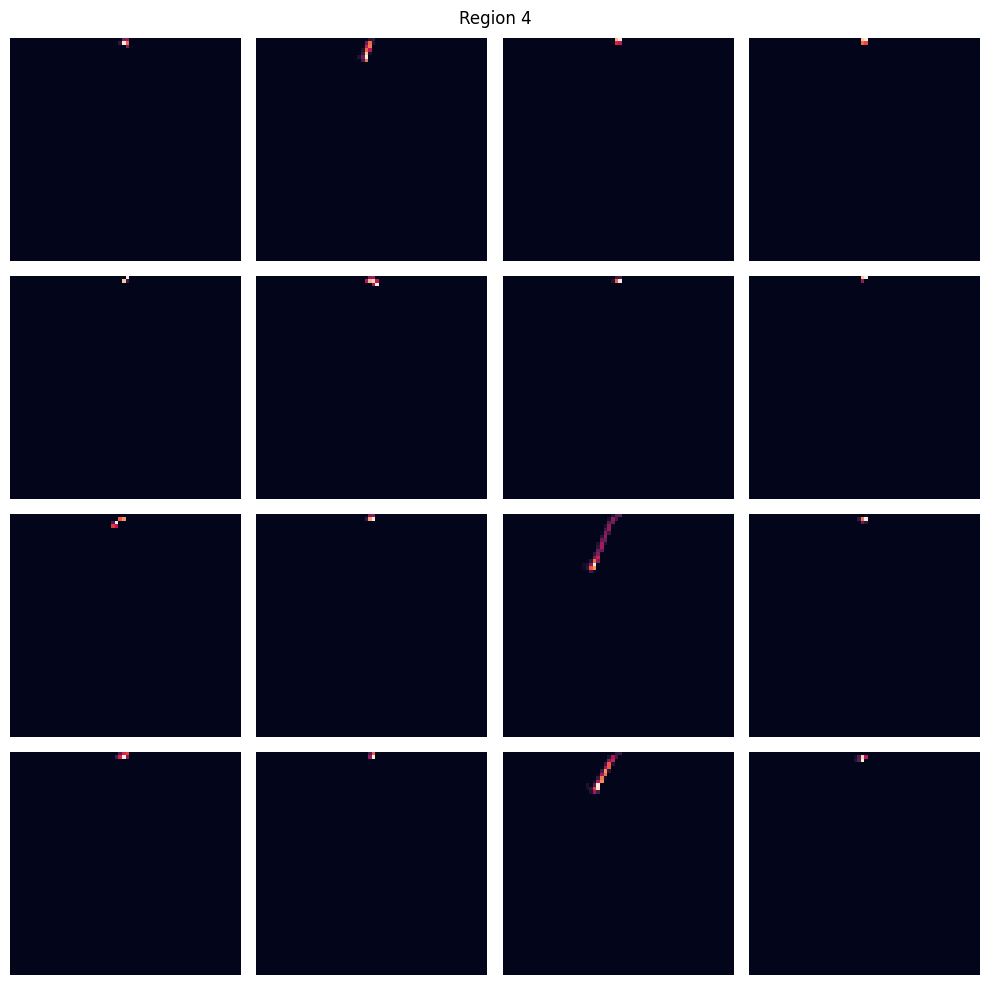

In [497]:
num_images = 16  # Number of images to display
grid_size = int(np.ceil(np.sqrt(num_images)))  # Grid dimensions (grid_size x grid_size)

# Filter the original images for the selected cluster
cluster_id = 4 # Change this to the desired cluster ID
cluster_mask = (labels_km == cluster_id)
cluster_indices = np.where(cluster_mask)[0]

# Randomly select up to `num_images` images from the cluster
if len(cluster_indices) > num_images:
    selected_indices = np.random.choice(cluster_indices, size=num_images, replace=False)
else:
    selected_indices = cluster_indices

selected_images = d[selected_indices]

fig, axes = plt.subplots(grid_size, grid_size, figsize=(10, 10))

for i in range(grid_size * grid_size):
    ax = axes[i // grid_size, i % grid_size]
    if i < len(selected_images):
        sns.heatmap(selected_images[i, 1], ax=ax, cbar=False, xticklabels=False, yticklabels=False)
    else:
        ax.axis('off')  # Turn off unused subplots

fig.suptitle(f'Region {cluster_id}')
plt.tight_layout()
plt.show()

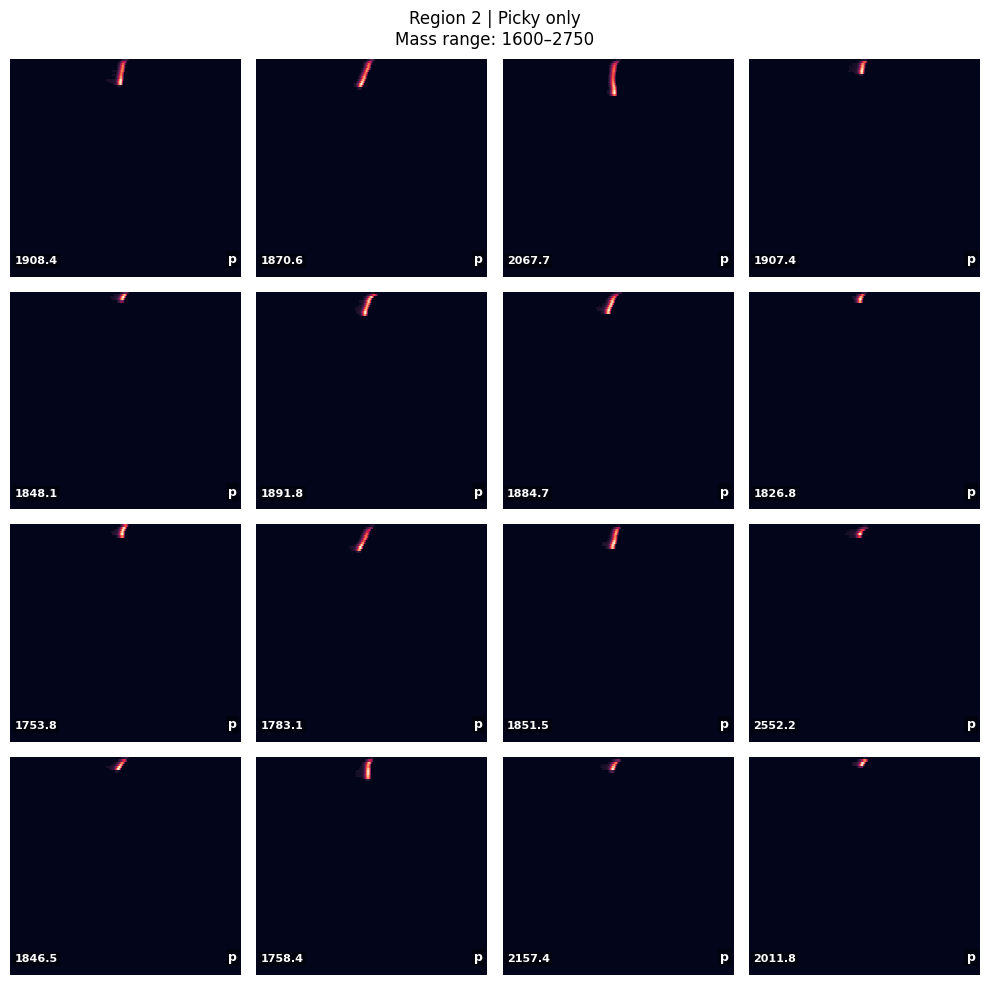

In [648]:
num_images = 16
grid_size = int(np.ceil(np.sqrt(num_images)))

# --- Selection parameters ---
cluster_id = 2
mass_min, mass_max = 1600, 2750
picky_only = True  # True = picky only, False = non-picky only, None = both

# --- Masks ---
cluster_mask = (labels_km == cluster_id)
mass_mask = (d_m >= mass_min) & (d_m <= mass_max)

if picky_only is True:
    picky_mask = (d_p == 1)
elif picky_only is False:
    picky_mask = (d_p == 0)
else:
    picky_mask = np.ones_like(d_p, dtype=bool)

combined_mask = cluster_mask & mass_mask & picky_mask
selected_indices = np.where(combined_mask)[0]

# --- Randomly select subset ---
if len(selected_indices) > num_images:
    selected_indices = np.random.choice(selected_indices, size=num_images, replace=False)

selected_images = deutimages[selected_indices]
selected_masses = d_m[selected_indices]
selected_picky = d_p[selected_indices]

# --- Plot ---
fig, axes = plt.subplots(grid_size, grid_size, figsize=(10, 10))

for i in range(grid_size * grid_size):
    ax = axes[i // grid_size, i % grid_size]
    if i < len(selected_images):
        sns.heatmap(selected_images[i, 1], ax=ax, cbar=False,
                    xticklabels=False, yticklabels=False)

        # --- Annotate mass (bottom-left) ---
        ax.text(0.02, 0.05, f"{selected_masses[i]:.1f}",
                transform=ax.transAxes,
                fontsize=8, color='white', ha='left', va='bottom',
                fontweight='bold',
                bbox=dict(facecolor='black', alpha=0.4, lw=0, pad=1.5))

        # --- Annotate 'p' if picky (bottom-right) ---
        if selected_picky[i] == 1:
            ax.text(0.98, 0.05, 'p',
                    transform=ax.transAxes,
                    fontsize=9, color='white', ha='right', va='bottom',
                    fontweight='bold',
                    bbox=dict(facecolor='black', alpha=0.4, lw=0, pad=1.5))
    else:
        ax.axis('off')

# --- Title ---
sel_type = (
    "Picky only" if picky_only is True else
    "Non-picky only" if picky_only is False else
    "All events"
)
fig.suptitle(f"Region {cluster_id} | {sel_type}\nMass range: {mass_min}–{mass_max}",
             fontsize=12)
plt.tight_layout()
plt.show()

In [409]:
# cluster_id = 3

# cluster_mask = (labels_km == cluster_id)
# cluster_indices = np.where(cluster_mask)[0]
# print(f"Cluster {cluster_id}: {len(cluster_indices)} samples")

# filtered_idx = cluster_indices[(RE_per_sample_d[cluster_indices] >= 0) &
#                                (RE_per_sample_d[cluster_indices] < 3000)]

# print(f"Filtered: {len(filtered_idx)} samples with RE in range")

# k = min(10, len(filtered_idx))
# if k == 0:
#     print(f"No samples found in cluster {cluster_id} with RE in range.")
# else:
#     selected = np.random.choice(filtered_idx, size=k, replace=False)

#     fig, axs = plt.subplots(k, 2, figsize=(6, 3*k))
#     for ii in range(k):
#         idx = selected[ii]
#         axs[ii, 0].imshow(Xd_np[idx], cmap='viridis', aspect='auto')
#         axs[ii, 0].set_title(f"Original (idx={idx}, RE={RE_per_sample_d[idx]:.1f})")
#         axs[ii, 0].axis('off')

#         axs[ii, 1].imshow(recon_all[idx], cmap='viridis', aspect='auto')
#         axs[ii, 1].set_title("Reconstruction")
#         axs[ii, 1].axis('off')

#     plt.tight_layout()
#     plt.show()

Deuteron subset shape: (5115, 2)


/var/folders/cm/m55y72dj6cd5lkwrfdb2bpnr0000gp/T/ipykernel_40836/859799654.py:16: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = plt.scatter(E_d[:, 0], E_d[:, 1], cmap='tab10', s=5, alpha=0.8)


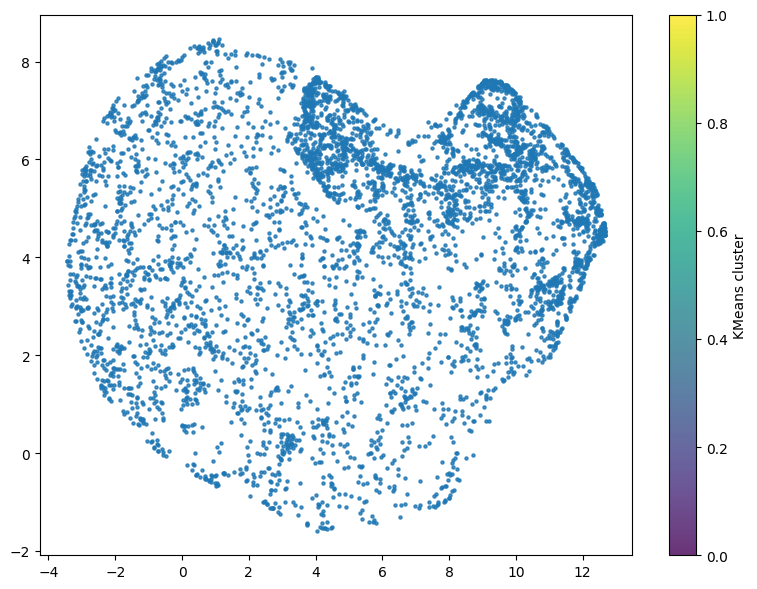

In [ ]:
Z_all = np.concatenate([latent_vectors, latent_vectors_d, latent_vectors_val], axis=0)
labels = np.concatenate([
    np.zeros(len(latent_vectors)),          # 0 = protons
    np.ones(len(latent_vectors_d)),         # 1 = deuterons
    np.full(len(latent_vectors_val), 2)     # 2 = validation
])

mask = (labels == 1)
Z_d = Z_all[mask]          # latent vectors
E_d = Z_umap[mask]      # 3D UMAP coordinates

print(f"Deuteron subset shape: {E_d.shape}")


fig = plt.figure(figsize=(8, 6))
sc = plt.scatter(E_d[:, 0], E_d[:, 1], cmap='tab10', s=5, alpha=0.8)
plt.colorbar(label='KMeans cluster')
ax.set_title("Deuteron candidates — KMeans clusters")
ax.set_xlabel("UMAP dim 1")
ax.set_ylabel("UMAP dim 2")
plt.tight_layout()
plt.show()


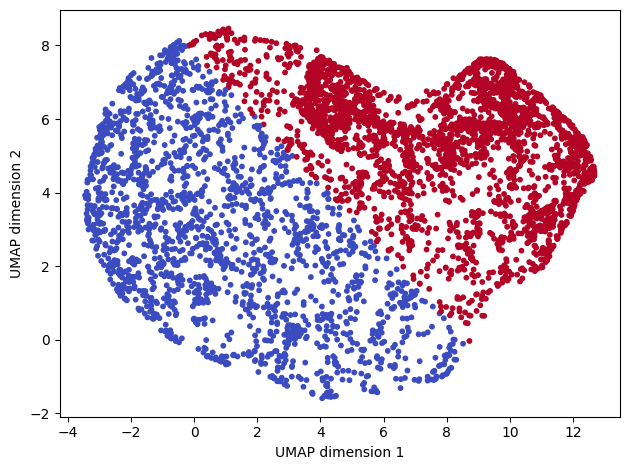

In [ ]:

# Example: UMAP coordinates
x = E_d[:, 0]
y = E_d[:, 1]

# Define your line: y = m*x + c
m = -0.9    # slope
c = 7.8    # intercept

# Compute which side each point is on
side = y > (m * x + c)
labels = side.astype(int)   # 0 or 1 cluster assignment

# Plot
# plt.figure(figsize=(7, 5))
plt.scatter(x, y, c=labels, cmap='coolwarm', s=10)
# plt.plot(x, m*x + c, 'k--', linewidth=2, label='Manual boundary')
plt.xlabel("UMAP dimension 1")
plt.ylabel("UMAP dimension 2")
# plt.legend()
plt.tight_layout()
plt.show()


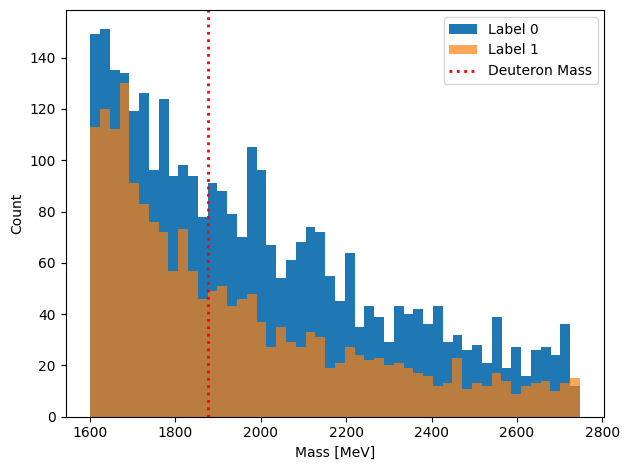

In [ ]:
mass_0 = d_m[(labels == 1)]
mass_1 = d_m[(labels == 0)]

# Plot
plt.hist(mass_0, bins=50, alpha=1.0, label='Label 0', color='tab:blue')
plt.hist(mass_1, bins=50, alpha=0.7, label='Label 1', color='tab:orange')
plt.axvline(1875.6, c='red', linestyle=':', linewidth=2, label='Deuteron Mass')

plt.xlabel('Mass [MeV]')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

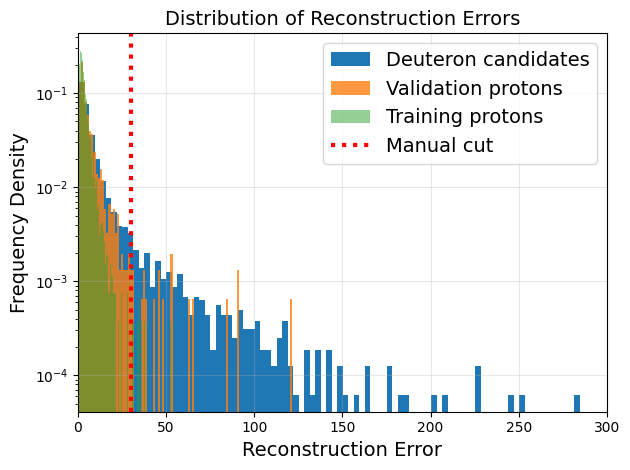

In [ ]:
# plt.figure(figsize=(12, 7))

plt.hist(RE_per_sample_d, bins=100, alpha=1, label='Deuteron candidates', density=True)
plt.hist(RE_per_sample_val, bins=100, alpha=0.8, label='Validation protons', density=True)
plt.hist(RE_per_sample, bins=100, alpha=0.5, label='Training protons', density=True)

plt.axvline(30, linewidth=3, linestyle=":", c='red', label='Manual cut')

plt.xlabel("Reconstruction Error", fontsize=14)
plt.ylabel("Frequency Density", fontsize=14)
plt.title("Distribution of Reconstruction Errors", fontsize=14)
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.xlim(0, 300)
plt.legend(fontsize=14)
plt.tight_layout()
plt.savefig('reconerror.png', dpi=1000)
plt.show()

In [ ]:
unique, counts = np.unique(labels, return_counts=True)
unique, counts

(array([0, 1]), array([1916, 3199]))

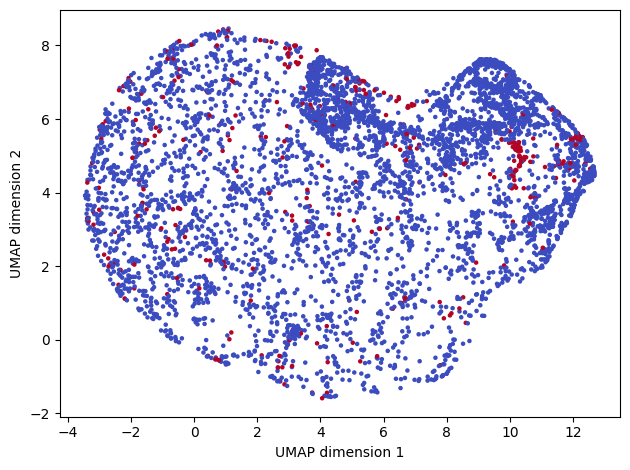

In [ ]:
labels = RE_per_sample_d > 30

x = E_d[:, 0]
y = E_d[:, 1]

plt.scatter(x, y, c=labels, cmap='coolwarm', s=5)
plt.xlabel("UMAP dimension 1")
plt.ylabel("UMAP dimension 2")
plt.tight_layout()
plt.show()


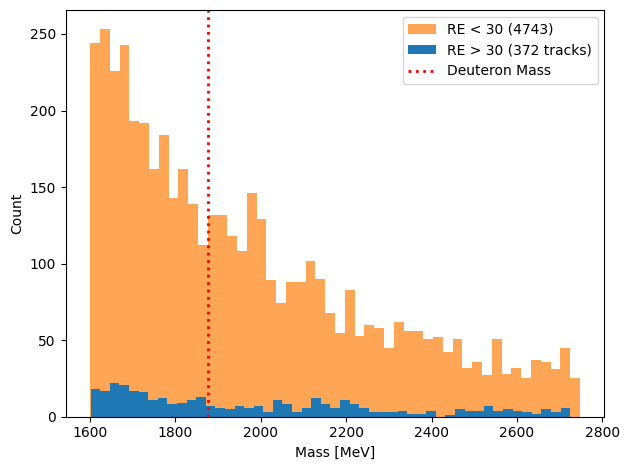

In [ ]:
mass_0 = d_m[(labels == 1)]
mass_1 = d_m[(labels == 0)]

# Plot

plt.hist(mass_1, bins=50, alpha=0.7, label='RE < 30 (4743)', color='tab:orange')
plt.hist(mass_0, bins=50, alpha=1.0, label='RE > 30 (372 tracks)', color='tab:blue')
plt.axvline(1875.6, c='red', linestyle=':', linewidth=2, label='Deuteron Mass')

plt.xlabel('Mass [MeV]')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

# ANGLE PROXY

<Axes: >

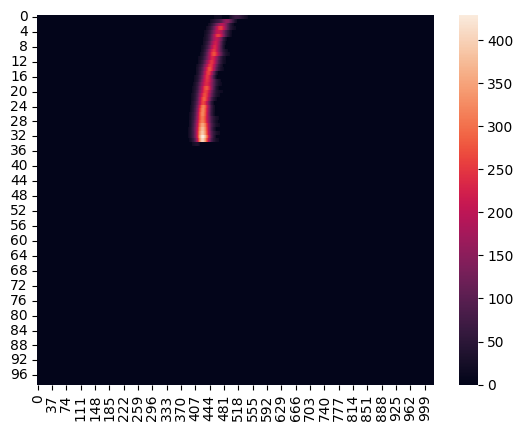

In [ ]:
sns.heatmap(p_c[1])

In [ ]:
height = col[col['particle_type'] == 'proton'].iloc[1]['height']
height

np.int64(35)

In [ ]:
a = p_c[1]
start = np.argmax(a[0,:])
end = np.argmax(a[34,:])

In [ ]:
end

np.int64(411)

In [ ]:
theta = np.arctan((start - end) / height)
theta = np.degrees(theta)
theta

np.float64(64.7760766026392)

In [ ]:
images = []

for idx, row in col.iterrows():
    padded = pad_image(
        row['image_intensity'])
    images.append(padded)

ind_images = []

for idx, row in ind.iterrows():
    padded = pad_image(
        row['image_intensity'])
    ind_images.append(padded)

In [ ]:
heights = col['height'].values
starts = np.array([np.argmax(img[0,:]) for img in images])
ends = np.array([np.argmax(img[h-1, :]) for img, h in zip(images, heights)])

thetas = np.arctan((starts - ends) / heights)
thetas = np.degrees(thetas)

col['thetas'] = thetas

In [ ]:
heights = ind['height'].values
starts = np.array([np.argmax(img[0,:]) for img in images])
ends = np.array([np.argmax(img[h-1, :]) for img, h in zip(images, heights)])

thetas = np.arctan((starts - ends) / heights)
thetas = np.degrees(thetas)

ind['thetas'] = thetas

(array([  8.,   7.,   4.,   6.,   8.,   2.,   3.,   0.,   3.,   5.,   3.,
          4.,   1.,   4.,   4.,   3.,   1.,   4.,   3.,   1.,   1.,   1.,
          2.,   1.,   2.,   4.,   2.,   4.,   0.,   4.,   3.,   2.,   2.,
          2.,   4.,   1.,   7.,   0.,   2.,   3.,   2.,   2.,   3.,   5.,
          2.,   2.,   3.,   1.,   3.,   1.,   2.,   5.,   1.,   4.,   4.,
          5.,   3.,   0.,   2.,   3.,   4.,   2.,   4.,   7.,   2.,   0.,
          3.,   6.,   2.,  10.,   0.,   1.,   6.,   3.,   2.,   7.,  10.,
          1.,   4.,   3.,   4.,   1.,   3.,   7.,   6.,   6.,   3.,   0.,
          5.,   3.,   4.,   4.,  10.,   7.,   6.,   3.,   6.,   4.,   5.,
          3.,   3.,  13.,   7.,   6.,  13.,   8.,   8.,   6.,  11.,  15.,
         13.,  13.,  15.,  15.,  15.,  18.,  25.,  20.,  15.,  30.,  33.,
         29.,  35.,  35.,  30.,  45.,  54.,  50.,  69.,  67., 100., 116.,
        121., 175., 163., 193., 218., 266., 306., 339., 395., 421., 511.,
        511., 474., 455., 392., 314., 

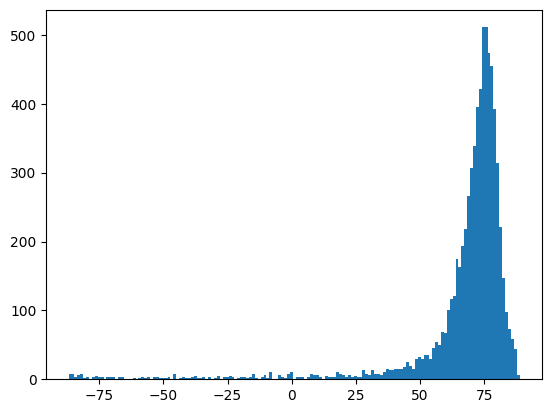

In [ ]:
plt.hist(col['thetas'], bins='auto')